# ID5059: Flight Delays
Investigating flight delays from several airports near New York over the course of one year. Fit at least two machine learning models and prepare a summary report for the Director of Operations of a major airport. Further information on the attributes of the nycflights13 dataset can be found [here](https://openflights.org/data.php).

**Research Questions:**
1. Can we predict, before a flight has departed, whether it will arrive late?
2. Which factors are most correlated with delays?

In [256]:
# Importing the required dependencies
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# For the pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# For modelling
from sklearn.linear_model import LogisticRegression, SGDClassifier # Good baseline models
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier # More robust models

# For hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# For model evaluation
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,   
    f1_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

## Creating the Training and Test Set

We are working with supervised data since we have the arr_delay for each flight. We will want to have an even split of arr_delay across the test/validation/training sets.

We will consider this a binary classification task (is a flight late or not) and use arr_delay to create a classification label is_delayed.

We should then examine the .csv files to look for which features may be useful to predict which flights will be delayed. Once we have a big table of everything we want to include, we should split the data into train / validation / test using a split. We will need a validation set to compare the different models we build before picking one to fine tune.

**Plan:**
1. Create a label is_delayed to classify whether a particular observation (row in flights.csv) is delayed or not
    * Are there any NA values for arr_delay? If so, what does that mean?
    * Decide whether to replace NA values or remove them
2. Check the distribution of delayed flights
3. Create analytical base table (ABT) with chosen high-level data
    * Is there any CSV data which is less useful which we can exclude?
4. Perform the train / validation / test split
5. Verify that the % of delays in the training set matches the % of the delays in the test set

### 1. Create new classifier is_delayed

Work on a copy of the data for reproducibility.

In [257]:
# Locate the file, read it in, and observe
flights_file_name = "../data/flights.csv"
flights_data = pd.read_csv(flights_file_name)
flights_data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00


In [258]:
# Check observations (shape[0]) and features (shape[1])
flights_data.shape

(336776, 19)

In [259]:
# Check for NA values
flights_data.isna().sum()

# 9430/336776 = 2.8% of the data is missing for arr_delay
# An NA arr_delay can't mean early (which is a negative number) or on time (which = 0)
# So we will assume it means the flight was cancelled
# We will drop these rows since it's small enough to drop without losing too much info


year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

In [260]:
# Drop the rows where arr_delay is NA since we can't create a label from this
flights_clean = flights_data.dropna(subset=['arr_delay']).copy()
flights_delay_not_null = flights_data['arr_delay'].notnull().sum()

# Sanity check all rows with NA arr_delay have been dropped
if flights_delay_not_null == flights_clean.shape[0]:
    print(f"Rows before drop: {flights_data.shape[0]}")
    print(f"Rows dropped: {flights_data.isna().sum()['arr_delay']}")
    print(f"Rows remaining: {flights_clean.shape[0]}")

Rows before drop: 336776
Rows dropped: 9430
Rows remaining: 327346


In [261]:
# We will assume that a flight is delayed if it arrives 15 minutes or more after its scheduled arrival time
# 1 = delayed, 0 otherwise
flights_clean['is_delayed'] = (flights_clean['arr_delay'] >= 15).astype(int)

# Sanity check is_delayed is categorising correctly
flights_clean[['arr_delay', 'is_delayed']].head(10)

,arr_delay,is_delayed
0,11.0,0
1,20.0,1
2,33.0,1
3,-18.0,0
4,-25.0,0
5,12.0,0
6,19.0,1
7,-14.0,0
8,-8.0,0
9,8.0,0


### 2. Check the distribution of delayed flights

If the dataset is imbalanced (eg 20% delays and 80% on-time) we will need to do a stratified split to ensure the train and test sets have similar proportions of delayed/on-time data.

In [262]:
# Check the proportion of delayed flights
print(flights_clean['is_delayed'].value_counts(normalize=True))

# The dataset is imbalanced (~25% flights are delayed) so we should use stratified splitting
# to ensure the proportion of delayed flights in the train / validation / test sets are similar

is_delayed
0    0.755305
1    0.244695
Name: proportion, dtype: float64


### 3. Create ABT with chosen high-level data

Common causes of aviation delays may be the schedule (time of flight or month), the operator (airline or origin airport), or the environment (weather conditions or distance).

After inspecting the .csv files, airports.csv and planes.csv seem like they would have low additional value versus the expense of including them in the ABT. We could explore if there's a relationship between older plane machinery (planes.csv) and flight delays, but this is not as obvious as the aforementioned assumptions (schedule, operator, and weather).

Therefore, we will use:
- **airlines.csv**
- **flights.csv**
- **weather.csv**

This will usefully simplify the model, but it may also narrow the scope of the data so the final model may be oblivious to some potential causes of delays. For the scope of this project, we will drop planes.csv and airports.csv to allow for deeper exploration of data which we assume is more likely to be important.

If I had more time I may explore geographical data (eg northbound vs southbound delays) or plane age data. 

In [263]:
# We need to merge flights.csv with airlines (for names) and weather (for weather info)

# Locate the weather file, read it in, and observe
weather_file_name = "../data/weather.csv"
weather_data = pd.read_csv(weather_file_name)
weather_data.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


In [264]:
# Check the features in more detail to identify potential features to merge with flights.csv
weather_data.info()

# Origin, year, month, day, and hour have no null entries (could be primary key)

<class 'pandas.DataFrame'>
RangeIndex: 26115 entries, 0 to 26114
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26115 non-null  str    
 1   year        26115 non-null  int64  
 2   month       26115 non-null  int64  
 3   day         26115 non-null  int64  
 4   hour        26115 non-null  int64  
 5   temp        26114 non-null  float64
 6   dewp        26114 non-null  float64
 7   humid       26114 non-null  float64
 8   wind_dir    25655 non-null  float64
 9   wind_speed  26111 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26115 non-null  float64
 12  pressure    23386 non-null  float64
 13  visib       26115 non-null  float64
 14  time_hour   26115 non-null  str    
dtypes: float64(9), int64(4), str(2)
memory usage: 3.0 MB


In [265]:
# Check if the combination of origin, year, month, day, and hour is unique in weather.csv
is_unique = weather_data.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# It's not, so identify all rows that have a duplicate combination of our keys
keys = ['origin', 'year', 'month', 'day', 'hour']
duplicates = weather_data[weather_data.duplicated(subset=keys, keep=False)]

print(f"Number of duplicate rows: {duplicates.shape[0]} / {weather_data.shape[0]}")

# Sort them so the duplicates are next to each other
duplicates.sort_values(by=keys).head(10)

# Twice a year there are two entries for each airport at the same hour on the same day
# We will assume this is due to clocks going forward / back for daylight savings time

Is the keyset unique: False
Number of duplicate rows: 6 / 26115


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
7318,EWR,2013,11,3,1,51.98,39.02,61.15,310.0,6.90468,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
7319,EWR,2013,11,3,1,50.00,39.02,65.80,290.0,5.75390,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
16023,JFK,2013,11,3,1,53.96,37.94,54.51,320.0,9.20624,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
16024,JFK,2013,11,3,1,51.98,37.94,58.62,310.0,6.90468,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
24729,LGA,2013,11,3,1,55.04,39.02,54.67,330.0,9.20624,NaN,0.0,1009.3,10.0,2013-11-03T05:00:00Z
24730,LGA,2013,11,3,1,53.96,39.92,58.89,310.0,8.05546,NaN,0.0,1010.2,10.0,2013-11-03T06:00:00Z


In [266]:
# Both entries have weather info for the same time so we will calculate a simple mean of numeric values
weather_data_unique = weather_data.groupby(keys).mean(numeric_only=True).reset_index()

# Verify after taking the mean that the keyset is now unique
is_unique = weather_data_unique.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# Sanity check the new dataframe looks as expected
weather_data_unique.head(10)

Is the keyset unique: True


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
5,EWR,2013,1,1,6,37.94,28.04,67.21,240.0,11.50780,NaN,0.0,1012.4,10.0
6,EWR,2013,1,1,7,39.02,28.04,64.43,240.0,14.96014,NaN,0.0,1012.2,10.0
7,EWR,2013,1,1,8,39.92,28.04,62.21,250.0,10.35702,NaN,0.0,1012.2,10.0
8,EWR,2013,1,1,9,39.92,28.04,62.21,260.0,14.96014,NaN,0.0,1012.7,10.0
9,EWR,2013,1,1,10,41.00,28.04,59.65,260.0,13.80936,NaN,0.0,1012.4,10.0


In [267]:
# Check the features in more detail to be sure
weather_data_unique.info()

# Number of rows has reduced from 26115 to 26112 after removing duplicates (3 pairs merged)
# So this is as expected

<class 'pandas.DataFrame'>
RangeIndex: 26112 entries, 0 to 26111
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26112 non-null  str    
 1   year        26112 non-null  int64  
 2   month       26112 non-null  int64  
 3   day         26112 non-null  int64  
 4   hour        26112 non-null  int64  
 5   temp        26111 non-null  float64
 6   dewp        26111 non-null  float64
 7   humid       26111 non-null  float64
 8   wind_dir    25652 non-null  float64
 9   wind_speed  26108 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26112 non-null  float64
 12  pressure    23383 non-null  float64
 13  visib       26112 non-null  float64
dtypes: float64(9), int64(4), str(1)
memory usage: 2.8 MB


In [268]:
# Perform a left join using the chosen keys, keep all flight info but adding new weather info
flights_weather = flights_clean.merge(weather_data_unique, on=keys, how='left')

# Sanity check the merge worked as expected
flights_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

In [269]:
# Check if carrier is null in flights_weather before joining
flights_weather['carrier'].isna().sum()

np.int64(0)

In [270]:
# Locate the airlines file, read it in, and observe
airlines_file_name = "../data/airlines.csv"
airlines_data = pd.read_csv(airlines_file_name)
airlines_data.head(20)

# Airlines.csv is a complete list of all carriers and their names

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,EV,ExpressJet Airlines Inc.
6,F9,Frontier Airlines Inc.
7,FL,AirTran Airways Corporation
8,HA,Hawaiian Airlines Inc.
9,MQ,Envoy Air


In [271]:
# Perform a left join on carrier to add airline names in case we want it for presenting analysis later
flights_weather_airlines = flights_weather.merge(airlines_data, on='carrier', how='left')

# Sanity check the merged dataframe is what we expect before doing any splitting
flights_weather_airlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

### 4. Perform train / test split

Bin the arr_delay (currently a numerical) into categories to ensure the train and test set get an equal share of on time, slightly late and majorly late flights

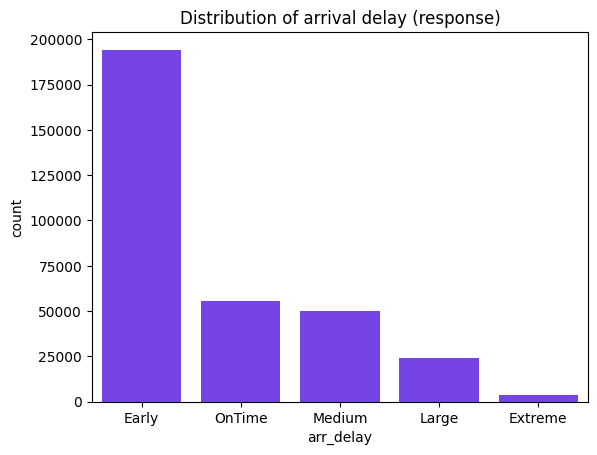

In [272]:
# Create the bins to split arr_delay into categories for stratificatoin
strat_bins = pd.cut(
    flights_weather_airlines['arr_delay'],
    bins=[-np.inf, 0, 15, 60, 180, np.inf],
    labels=['Early', 'OnTime', 'Medium', 'Large', 'Extreme']
)

# View the distribution of the bins
sns.countplot(x=strat_bins, color='#6c28ff')
plt.title('Distribution of arrival delay (response)')
plt.show()

# This confirms the distribution is imbalanced so we should use stratified sampling

In [273]:
# We will use a stratified shuffle split using the bins we create
# We will do one split to get the (training & validation) group and the test group
shuffled_data = StratifiedShuffleSplit(
    n_splits=1, # We are only splitting once for a train & test set
    test_size=0.2, # Test set will be 20% of the data
    random_state=42 # Set seed to maintain split and reproducibility (Geron always uses 42)
)

# Create indexes based on the 5 bins
[(train_val_index, test_index)] = shuffled_data.split(
    flights_weather_airlines,
    strat_bins
)

# Create the train_val and test sets using the calculated indexes
flights_train_val_raw = flights_weather_airlines.iloc[train_val_index].copy()
flights_test_raw = flights_weather_airlines.iloc[test_index].copy()

Create a validation set which will be used to train the model which performed best on the training set.

In [274]:
# Make new bins with the dimensions for the (training & validation) set
train_val_strat_bins = pd.cut(
    flights_train_val_raw['arr_delay'],
    bins=[-np.inf, 0, 15, 60, 180, np.inf],
    labels=['Early', 'OnTime', 'Medium', 'Large', 'Extreme']
)

shuffled_data_validation = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.25, # 25% of the training set (80%) is 20%
    random_state=42
)

[(train_index, val_index)] = shuffled_data.split(
    flights_train_val_raw,
    train_val_strat_bins
)

# Use the new indexes to split the (training & validation) set into the training and validation set
flights_train_raw = flights_train_val_raw.iloc[train_index].copy()
flights_validation_raw = flights_train_val_raw.iloc[val_index].copy()

### 5. Verify that the Training & Test Set have similar delay distributions

  delay_category     train  validation      test
0          Early  0.593690    0.593688  0.593692
1         OnTime  0.169160    0.169161  0.169161
2         Medium  0.152258    0.152264  0.152253
3          Large  0.073155    0.073144  0.073148
4        Extreme  0.011737    0.011742  0.011746


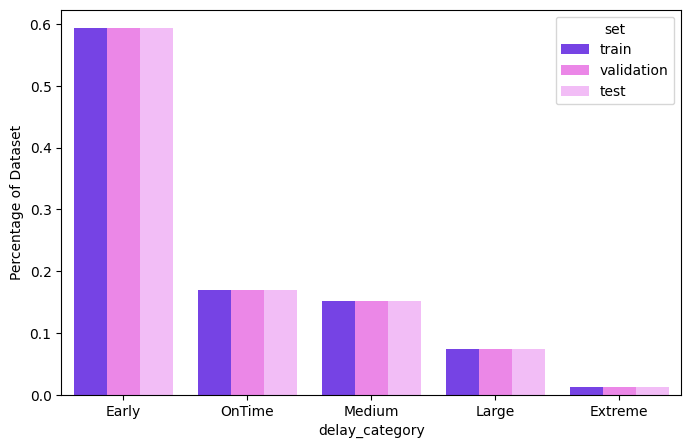

In [275]:
# Get the distribution of the bins in each set to check stratification worked
train_dist = train_val_strat_bins.iloc[train_index].value_counts(normalize=True)
val_dist = train_val_strat_bins.iloc[val_index].value_counts(normalize=True)
test_dist = strat_bins.iloc[test_index].value_counts(normalize=True)

# Combine and reset index to compare the distributions across train / validation /test sets
dist_df = pd.DataFrame({'train': train_dist, 'validation': val_dist, 'test': test_dist}).reset_index()
dist_df.columns = ['delay_category', 'train', 'validation','test']

# Check the raw distribution numbers
print(dist_df)

# Plot for easy comparison
dist_melted = dist_df.melt(id_vars='delay_category', var_name='set', value_name='percentage')
my_palette = ['#6c28ff','#fc76f7', "#fab4ff"]

plt.figure(figsize=(8,5))
sns.barplot(data=dist_melted, x='delay_category', y='percentage', hue='set', palette=my_palette)
plt.ylabel('Percentage of Dataset')
plt.show()

## Data Wrangling

From this point forward, this is on the **TRAINING SET ONLY**. We will use a copy of the training set to freely explore the data before manipulating the actual training data.


**Plan:**
1. Read in the data
2. Data Cleaning
    * Check data types
    * Convert any incorrect columns
    * Check for missing values
3. Data Exploration
    * Look for unique identifiers
    * Look at feature distributions
    * Look for any order in the data
    * Look for relationships with response
    * Check correlations
4. Revised Data Cleaning
    * Make decisions based off of data exploration
5. (Exploring) Feature Engineering
    * Are there any numerical features which may be more useful as categories?

### 1. Read in the data

In [276]:
# All data exploration will be done on a copy of the training set to freely explore the data
# The final pipeline based off of the exploration will use the actual training set
flights_train_copy = flights_train_raw.copy()

flights_train_copy.info()

<class 'pandas.DataFrame'>
Index: 209500 entries, 59674 to 186079
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            209500 non-null  int64  
 1   month           209500 non-null  int64  
 2   day             209500 non-null  int64  
 3   dep_time        209500 non-null  float64
 4   sched_dep_time  209500 non-null  int64  
 5   dep_delay       209500 non-null  float64
 6   arr_time        209500 non-null  float64
 7   sched_arr_time  209500 non-null  int64  
 8   arr_delay       209500 non-null  float64
 9   carrier         209500 non-null  str    
 10  flight          209500 non-null  int64  
 11  tailnum         209500 non-null  str    
 12  origin          209500 non-null  str    
 13  dest            209500 non-null  str    
 14  air_time        209500 non-null  float64
 15  distance        209500 non-null  int64  
 16  hour            209500 non-null  int64  
 17  minute          209500

In [277]:
flights_train_copy.shape
# There are 261876 observations and 30 features

(209500, 30)

### 2. Data Cleaning

In [278]:
# Check the data types of features to see if they match expectations
flights_train_copy.dtypes.to_frame(name='Data Type')

# It seems like month, carrier (airline code), origin, dest, and name (of airline) should be categorical,
# but they are numerical or object types currently so we will convert these

,Data Type
year,int64
month,int64
day,int64
dep_time,float64
sched_dep_time,int64
dep_delay,float64
arr_time,float64
sched_arr_time,int64
arr_delay,float64
carrier,str


Converting column types in the data to the correct types.

In [279]:
# List out the columns to change type into a category
category_columns = ["month", "carrier", "origin", "dest", "hour", "name"]

# Convert the types
flights_train_copy[category_columns] = flights_train_copy[category_columns].astype('category')

# Check the data types have been updated correctly
flights_train_copy.dtypes.to_frame(name='Updated Data Type')

,Updated Data Type
year,int64
month,category
day,int64
dep_time,float64
sched_dep_time,int64
dep_delay,float64
arr_time,float64
sched_arr_time,int64
arr_delay,float64
carrier,category


Checking for missing values.

In [280]:
# Converting to a dataframe for readability
flights_train_copy.isna().sum(axis=0).to_frame(name='# of Missing Values')

,# of Missing Values
year,0
month,0
day,0
dep_time,0
sched_dep_time,0
dep_delay,0
arr_time,0
sched_arr_time,0
arr_delay,0
carrier,0


We can see that out of the training set's 261876 entries, there is a lot of weather data missing. `wind_gust` and `pressure` have the most missing data, so we will drop these now.

We also need to consider:
* `temp` (1230)
* `dewp` (1230)
* `humid` (1230)
* `wind_dir` (7646)
* `wind_speed` (1282)
* `precip` (1216)
* `visib` (1216)

`wind_speed`, `precip`, and `visib` seem like they might be crucial so we will potentially keep these. But it would be better to investigate the data more before making decisions on any of these.

In [281]:
# Drop wind_gust and pressure from the training set now
flights_train_copy = flights_train_copy.drop(columns=['wind_gust', 'pressure'])

# Sanity check they've been dropped correctly
flights_train_copy.info()

<class 'pandas.DataFrame'>
Index: 209500 entries, 59674 to 186079
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   year            209500 non-null  int64   
 1   month           209500 non-null  category
 2   day             209500 non-null  int64   
 3   dep_time        209500 non-null  float64 
 4   sched_dep_time  209500 non-null  int64   
 5   dep_delay       209500 non-null  float64 
 6   arr_time        209500 non-null  float64 
 7   sched_arr_time  209500 non-null  int64   
 8   arr_delay       209500 non-null  float64 
 9   carrier         209500 non-null  category
 10  flight          209500 non-null  int64   
 11  tailnum         209500 non-null  str     
 12  origin          209500 non-null  category
 13  dest            209500 non-null  category
 14  air_time        209500 non-null  float64 
 15  distance        209500 non-null  int64   
 16  hour            209500 non-null  category
 17  min

### 3. Data Exploration

The aim of this is to find out for each feature:
* Name, description, meaning
* Type (categorical, numerical, text)
* Missing values
* Noisiness and type of noise
* Usefulness!
* Distribution
* Is it a unique identifier?

Some of this information can be found on the [nycflights13 webpage](https://openflights.org/data.php) or for this specific dataset in `../data/dictionary.md`.

In [282]:
flights_train_copy.nunique().to_frame(name='# of Unique Values')

# Remember there are 261876 rows
# From this we can see that no two features have the same number of unique values
# Other numeric columns don't have unique values either (they are much smaller than 261876)
# So we don't need to exclude anything based on this

,# of Unique Values
year,1
month,12
day,31
dep_time,1297
sched_dep_time,1014
dep_delay,484
arr_time,1402
sched_arr_time,1156
arr_delay,534
carrier,16


We will plot the distribution for each feature to see if there are any patterns.

Continuous features we will look at are:
* temp
* dewp
* humid
* wind_speed
* precip
* visib
* distance

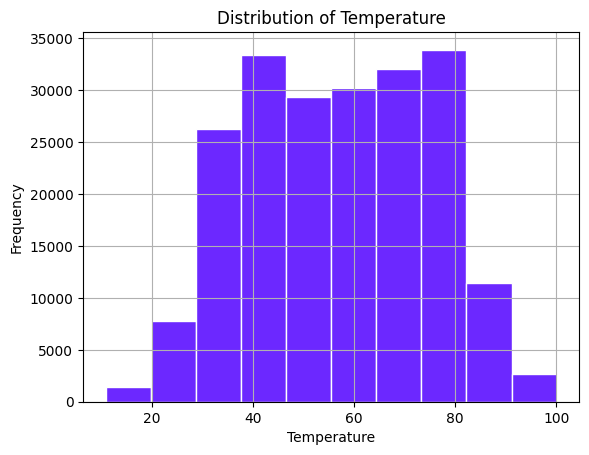

In [283]:
flights_train_copy['temp'].hist(color='#6c28ff', edgecolor='white')

plt.title('Distribution of Temperature')
plt.ylabel('Frequency')
plt.xlabel('Temperature')
plt.show()
# This distribution is roughly normal so we could use a median imputation strategy for missing values here

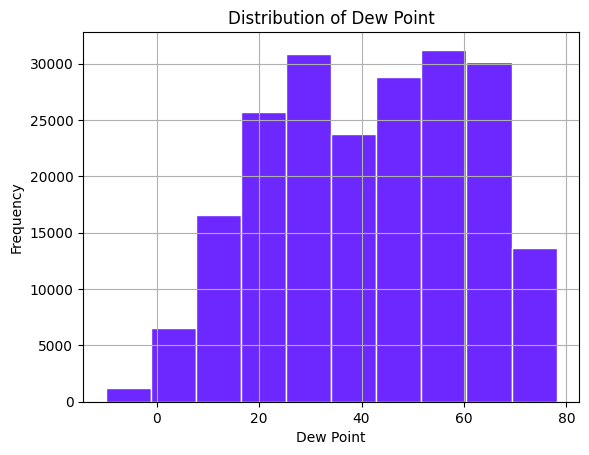

In [284]:
flights_train_copy['dewp'].hist(color='#6c28ff', edgecolor='white')

plt.title('Distribution of Dew Point')
plt.ylabel('Frequency')
plt.xlabel('Dew Point')
plt.show()
# This distribution is also roughly normal so we will use a median imputation strategy

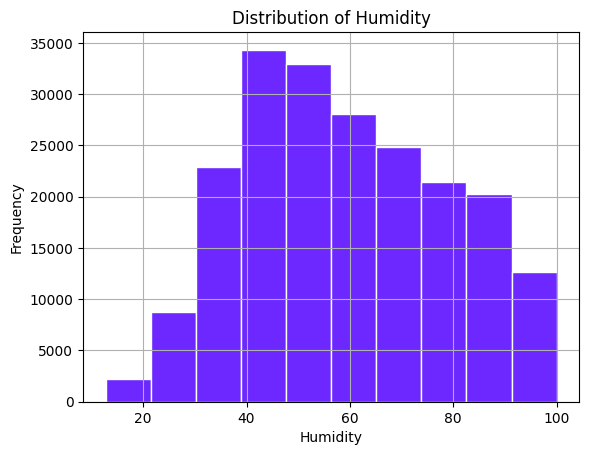

In [285]:
flights_train_copy['humid'].hist(color='#6c28ff', edgecolor='white')

plt.title('Distribution of Humidity')
plt.ylabel('Frequency')
plt.xlabel('Humidity')
plt.show()
# This distribution is also roughly normal so we will use a median imputation strategy

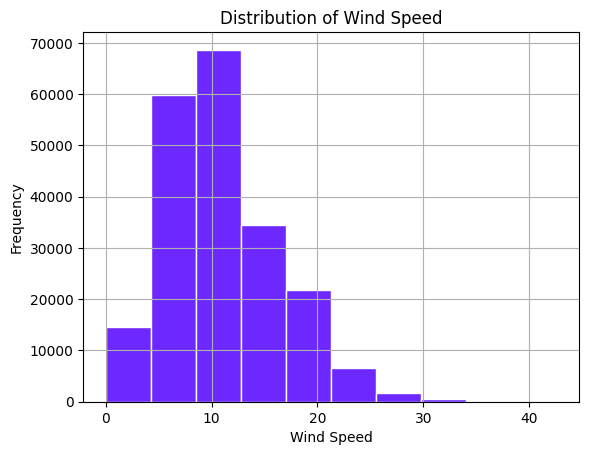

In [286]:
flights_train_copy['wind_speed'].hist(color='#6c28ff', edgecolor='white')

plt.title('Distribution of Wind Speed')
plt.ylabel('Frequency')
plt.xlabel('Wind Speed')
plt.show()
# This distribution is roughly normal but right skewed
# We will still use a median imputation strategy for missing values here
# Because the mean would be pulled up by the long tails on the left

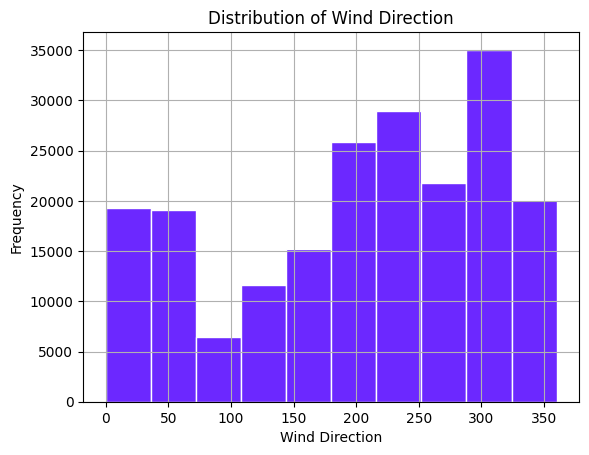

In [287]:
flights_train_copy['wind_dir'].hist(color='#6c28ff', edgecolor='white')

plt.title('Distribution of Wind Direction')
plt.ylabel('Frequency')
plt.xlabel('Wind Direction')
plt.show()

# There doesn't seem to be a clear distribution here
# Would probably end up dropping this depending on its correlation with the response

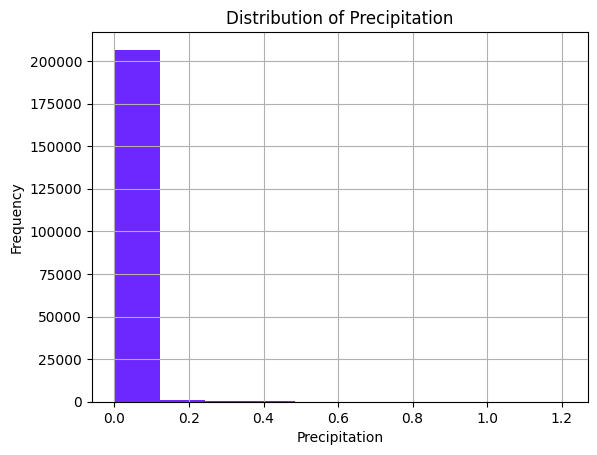

In [288]:
flights_train_copy['precip'].hist(color='#6c28ff')

plt.title('Distribution of Precipitation')
plt.ylabel('Frequency')
plt.xlabel('Precipitation')
plt.show()
# Here it is suitable to fill in missing values with the mode (0)
# Since the vast majority of values are 0 so the mode is more representative
# But we should still note the graph plots up to 1.2 so there are some non-zero values to be aware of

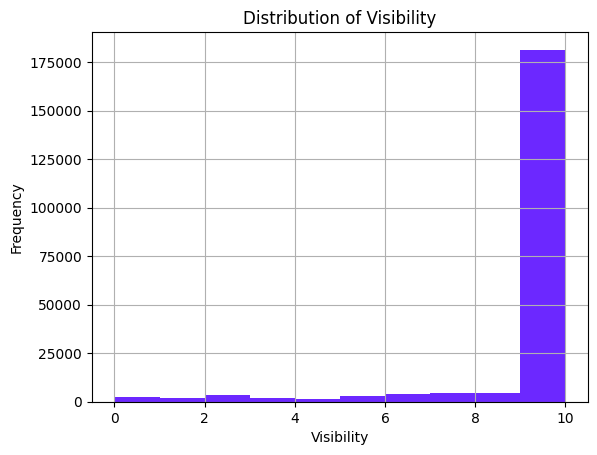

In [289]:
flights_train_copy['visib'].hist(color='#6c28ff')

plt.title('Distribution of Visibility')
plt.ylabel('Frequency')
plt.xlabel('Visibility')
plt.show()
# Again, missing values should probably be filled in with the mode (10)

Mean distance: 1048.9366443914082
Median distance: 888.0


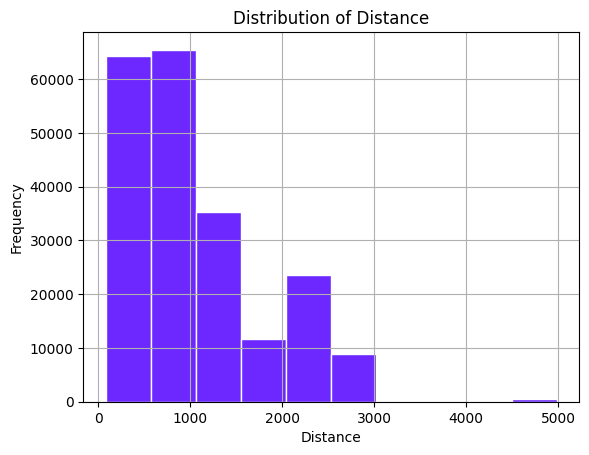

In [290]:
flights_train_copy['distance'].hist(color='#6c28ff', edgecolor='white')

mean_distance = flights_train_copy['distance'].mean()
median_distance = flights_train_copy['distance'].median()

print(f"Mean distance: {mean_distance}"
      f"\nMedian distance: {median_distance}")

plt.title('Distribution of Distance')
plt.ylabel('Frequency')
plt.xlabel('Distance')
plt.show()
# This distribution is right skewed with long tails
# We will also use a median imputation strategy for missing values here
# Since the mean would be pulled up by the long tails

Categorical features to look at are:
* origin
* dest
* carrier / name
* month
* hour

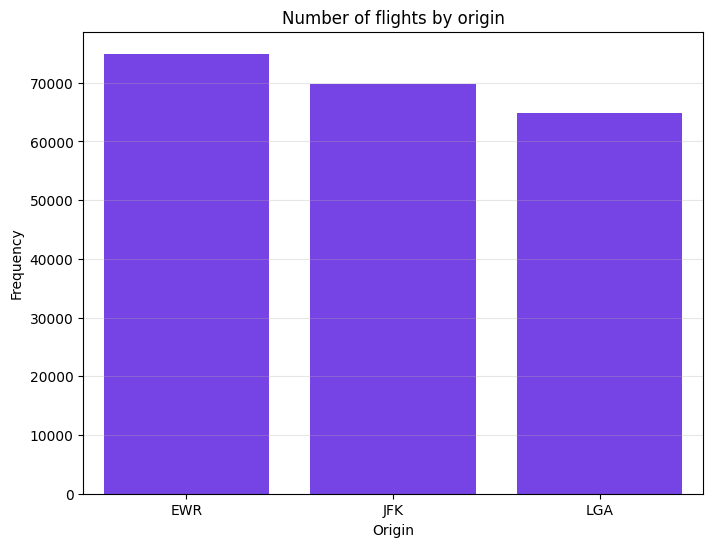

In [291]:
plt.figure(figsize=(8, 6))
sns.countplot(data=flights_train_copy, x='origin', color="#6c28ff")

plt.title('Number of flights by origin')
plt.ylabel('Frequency')
plt.xlabel('Origin')
plt.grid(axis='y', alpha=0.3)
plt.show()
# EWR operates the most flights, followed by JFK and then LGA

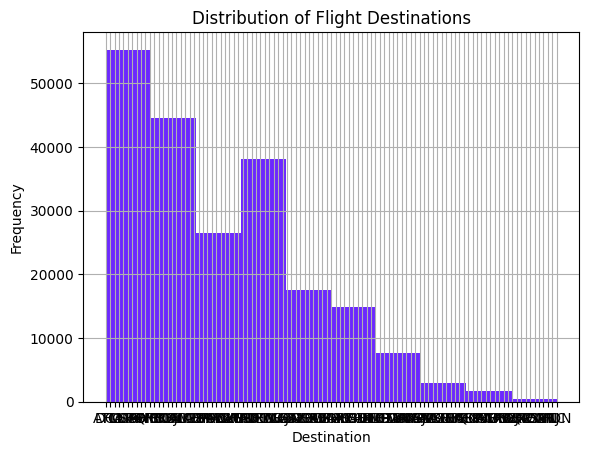

In [292]:
flights_train_copy['dest'].hist(color='#6c28ff')

plt.title('Distribution of Flight Destinations')
plt.ylabel('Frequency')
plt.xlabel('Destination')
plt.show()
# There's no "obvious" destination that we would want to impute missing values with
# Potentially come up with an "unknown" category for missing values here

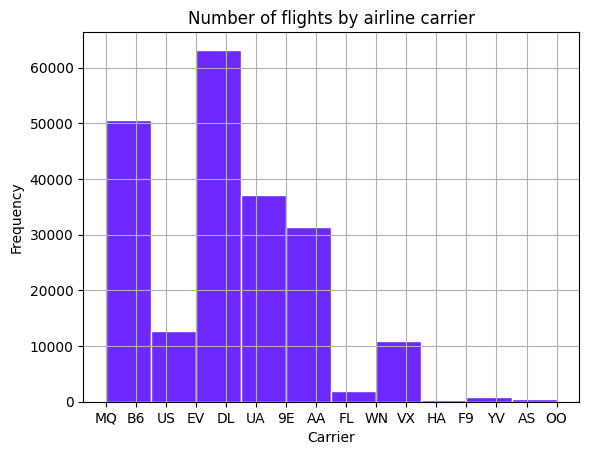

In [293]:
flights_train_copy['carrier'].hist(color='#6c28ff', edgecolor='white')

plt.title('Number of flights by airline carrier')
plt.ylabel('Frequency')
plt.xlabel('Carrier')
plt.show()
# There's no "obvious" destination that we would want to impute missing values with
# Potentially come up with an "unknown" category for missing values here

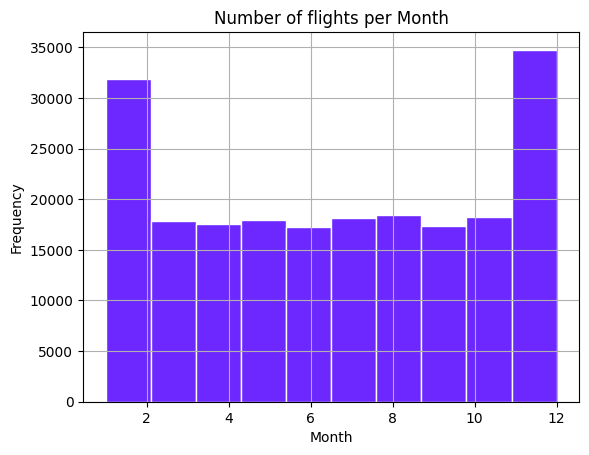

In [294]:
flights_train_copy['month'].hist(color='#6c28ff', edgecolor='white')

plt.title('Number of flights per Month')
plt.ylabel('Frequency')
plt.xlabel('Month')
plt.show()
# The largest number of flights are recorded over christmas
# But it doesn't make much sense to just assume a flight happens at this time
# Would either drop rows with missing month or potentially come up with an "unknown" category here

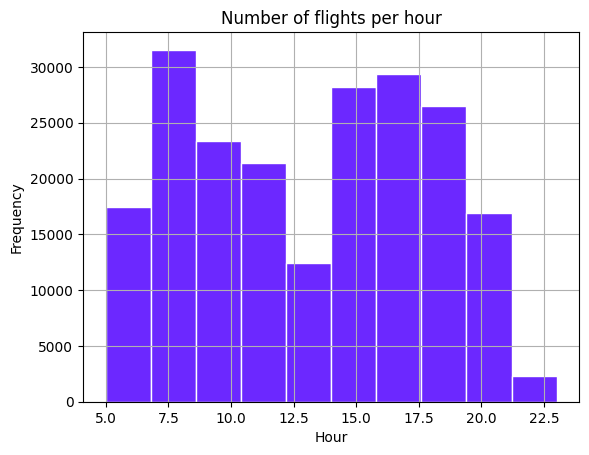

In [295]:
flights_train_copy['hour'].hist(color='#6c28ff', edgecolor='white')

plt.title('Number of flights per hour')
plt.ylabel('Frequency')
plt.xlabel('Hour')
plt.show()
# There are two peaks in the distribution of flight times
# Could impute missing values with one of these peaks or delete rows

Looking for any order in the data.

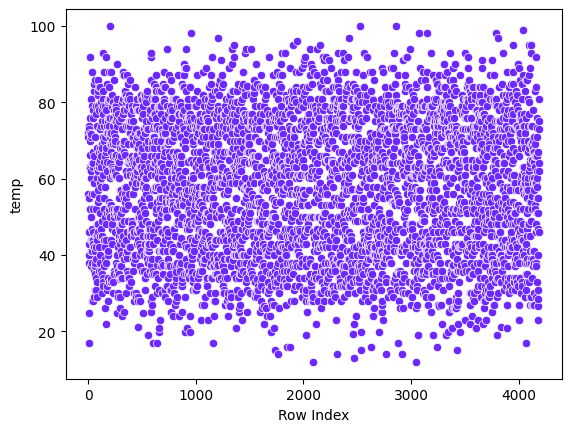

In [296]:
# Visualise a subset of the data since it's so large
# After trying out 100k, 10k and 1k, a subset of size ~5k gives a good balance of visualising the data clearly
# So we will take every 50th value
subset = flights_train_copy.iloc[::50]

sns.scatterplot(x=list(range(len(subset))), y=subset['temp'], color='#6c28ff')
plt.xlabel('Row Index')
plt.show()

# There is no obvious pattern in the ordering of the temperature feature

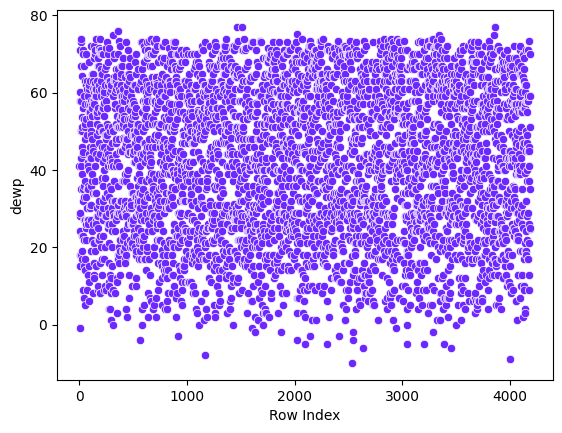

In [297]:
sns.scatterplot(x=list(range(len(subset))), y=subset['dewp'], color='#6c28ff')
plt.xlabel('Row Index')
plt.show()

# There is no obvious pattern in the ordering of the dew point feature

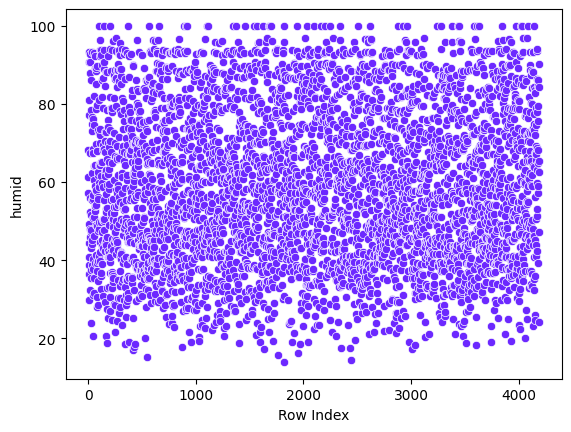

In [298]:
sns.scatterplot(x=list(range(len(subset))), y=subset['humid'], color='#6c28ff')
plt.xlabel('Row Index')
plt.show()

# There is no obvious pattern in the ordering of the humidity feature

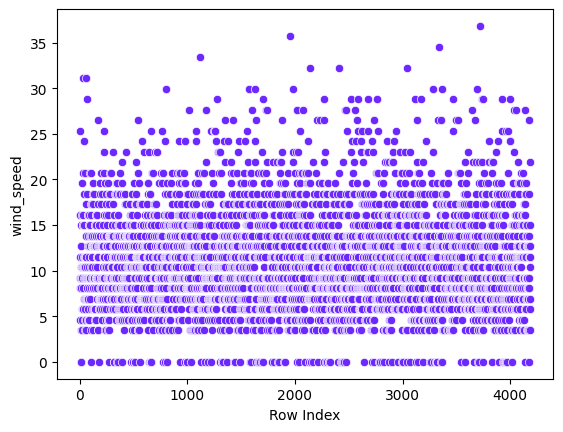

In [299]:
sns.scatterplot(x=list(range(len(subset))), y=subset['wind_speed'], color='#6c28ff')
plt.xlabel('Row Index')
plt.show()

# There is no obvious pattern in the ordering of the wind_speed feature

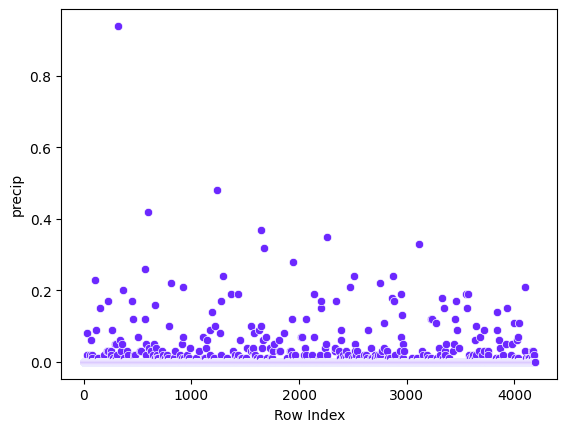

In [300]:
sns.scatterplot(x=list(range(len(subset))), y=subset['precip'], color='#6c28ff')
plt.xlabel('Row Index')
plt.show()

# There is no obvious pattern in the ordering of the precipitation feature

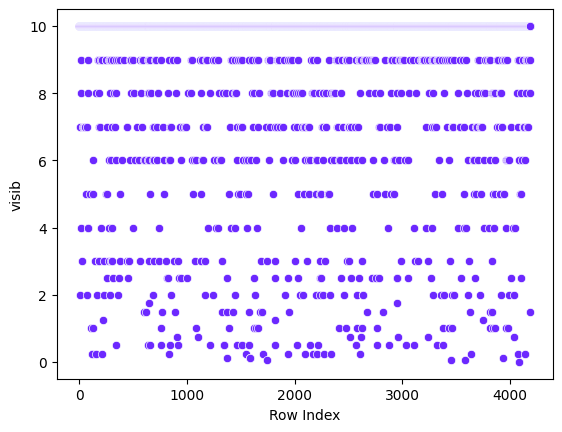

In [301]:
sns.scatterplot(x=list(range(len(subset))), y=subset['visib'], color='#6c28ff')
plt.xlabel('Row Index')
plt.show()

# There is no obvious pattern in the ordering of the visibility feature
# We could consider changing this into a categorical feature with bins for different levels of visibility
# Eg 0-3, 4-7, 8-10 and an "unknown" category for missing values

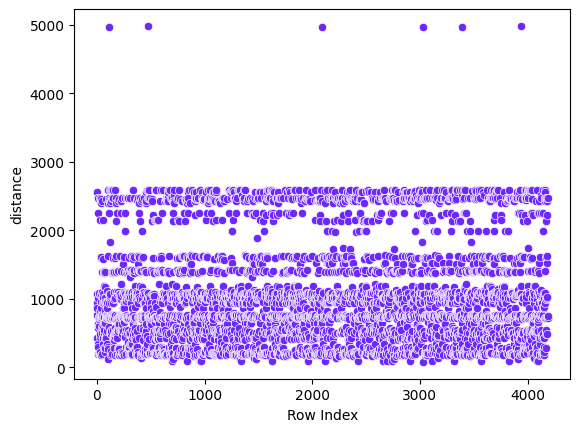

In [302]:
sns.scatterplot(x=list(range(len(subset))), y=subset['distance'], color='#6c28ff')
plt.xlabel('Row Index')
plt.show()

# There is no obvious pattern in the ordering of the distance feature

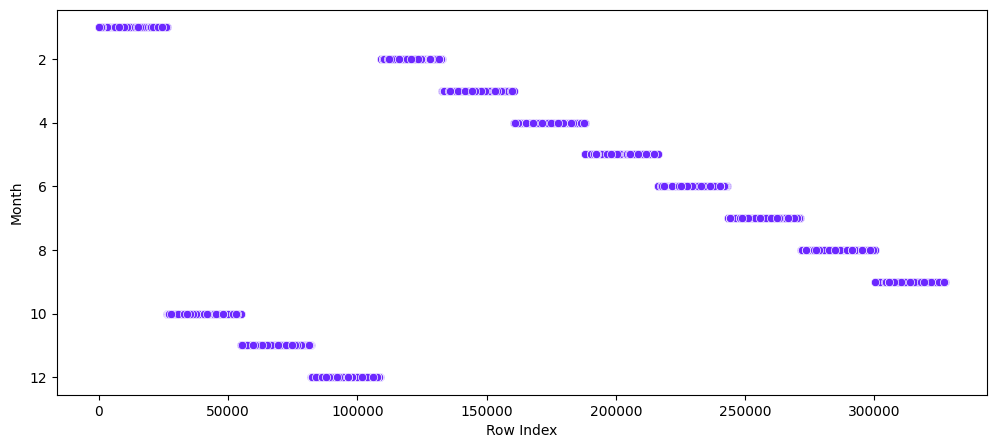

In [303]:
# When observing the raw data it looked chronologically ordered in some way
# Let's visualise the pattern

plt.figure(figsize=(12, 5))
sns.scatterplot(x=subset.index, y=subset['month'], color='#6c28ff')
plt.ylabel("Month")
plt.xlabel("Row Index")
plt.show()

# Months have been ordered: 1, 10, 11, 12, 2, 3, 4, 5, 6, 7, 8, 9
# Make sure to shuffle the data before modelling to avoid any issues with this ordering

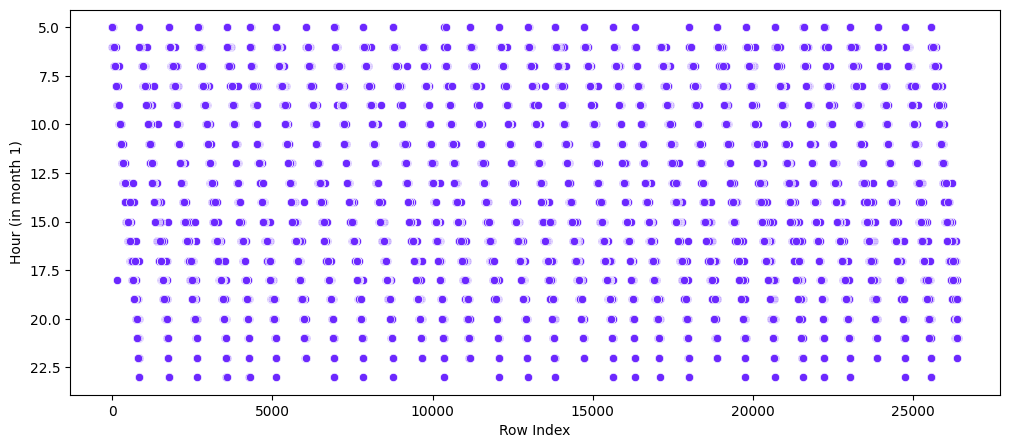

In [304]:
# Let's look at each month separately to see the pattern more clearly
month_num = 1
month_subset = flights_train_copy[flights_train_copy['month'] == month_num]

plt.figure(figsize=(12, 5))
sns.scatterplot(x=month_subset.index, y=month_subset['hour'], color='#6c28ff')
plt.ylabel(f"Hour (in month {month_num})")
plt.xlabel("Row Index")
plt.show()

# It looks like hour increases from 5 to 23 for a day and then resets for any month (change 1 to 2, 3 to see same pattern)
# Another reason why we must shuffle the data when splitting

Look for relationships with the response feature (is_delayed) to see what might be a key predictor in the model.

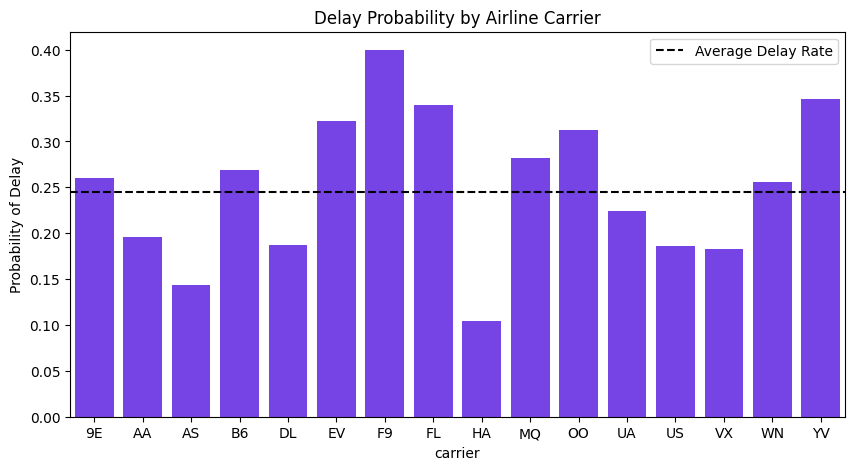

In [305]:
# Check if particular airline carrier have a relationship with delays by calculating the mean delay probability for each carrier
carrier_rel = flights_train_copy.groupby('carrier')['is_delayed'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=carrier_rel.index, y=carrier_rel.values, color='#6c28ff')
plt.title('Delay Probability by Airline Carrier')
plt.axhline(flights_train_copy['is_delayed'].mean(), color="#000000", linestyle='--', label='Average Delay Rate')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like some airlines (F9, FL, YV, and EV) clearly have higher delay probabilities than others
# This may be a valuable predictor

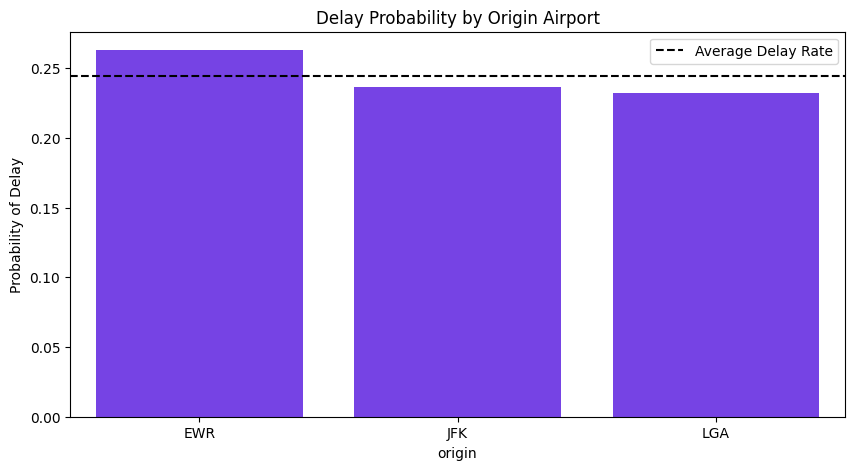

In [306]:
# Check if particular origin airports have a relationship with delays by calculating the mean delay probability for each origin
origin_rel = flights_train_copy.groupby('origin')['is_delayed'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=origin_rel.index, y=origin_rel.values, color='#6c28ff')
plt.title('Delay Probability by Origin Airport')
plt.axhline(flights_train_copy['is_delayed'].mean(), color="#000000", linestyle='--', label='Average Delay Rate')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like each airport has a different delay probability
# So this may also be a valuable predictor

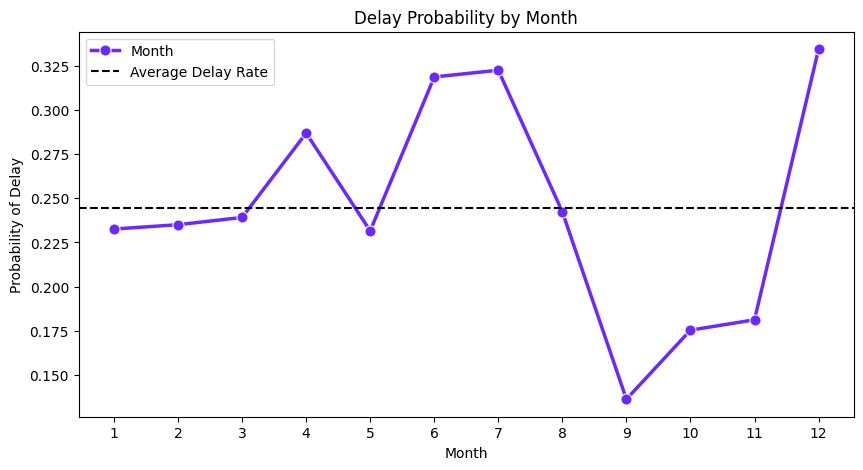

In [307]:
month_rel = flights_train_copy.groupby('month')['is_delayed'].mean().sort_values(ascending=False)

# A line plot is more suitable for temporal data since it shows the trend more clearly than a bar plot
plt.figure(figsize=(10,5))
sns.lineplot(
    x=month_rel.index,
    y=month_rel.values,
    marker='o', 
    markersize=8,
    color='#6c28ff',
    linewidth=2.5,
    label='Month'
)
plt.title('Delay Probability by Month')
plt.xticks(range(1, 13))
plt.axhline(flights_train_copy['is_delayed'].mean(), color="#000000", linestyle='--', label='Average Delay Rate')
plt.xlabel('Month')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like there is a clear relationship between month and delay probability
# Summer months (June and July) and Christmas holidays (December) appear to have higher delay probabilities than other months
# This looks like it will be a valuable predictor

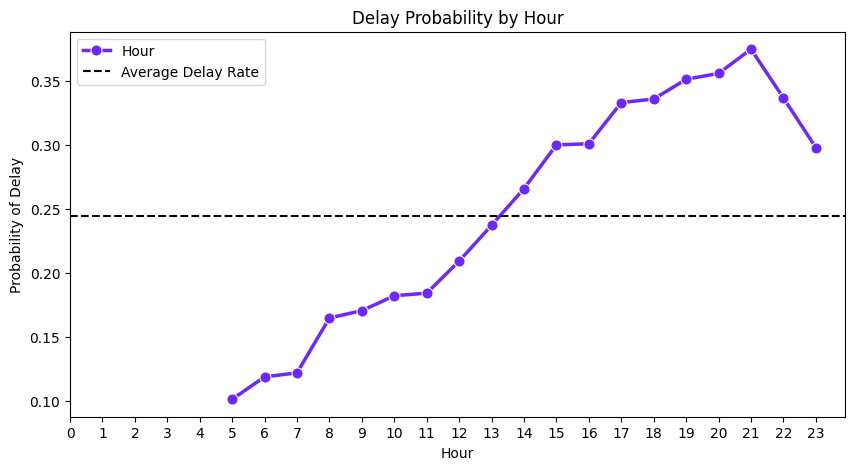

In [308]:
hour_rel = flights_train_copy.groupby('hour')['is_delayed'].mean().sort_values(ascending=False)

# A line plot is more suitable for this data as well
plt.figure(figsize=(10,5))
sns.lineplot(
    x=hour_rel.index,
    y=hour_rel.values,
    marker='o', 
    markersize=8,
    color='#6c28ff',
    linewidth=2.5,
    label='Hour'
)
plt.title('Delay Probability by Hour')
plt.xticks(range(0, 24))
plt.axhline(flights_train_copy['is_delayed'].mean(), color="#000000", linestyle='--', label='Average Delay Rate')
plt.xlabel('Hour')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like there is a clear relationship between hour and delay probability as well
# Flights become more likely to be delayed as the day goes on
# This will also likely be a valuable predictor

For the continuous features we will mainly use box plots to observe any potential relationships with the response is_delayed.

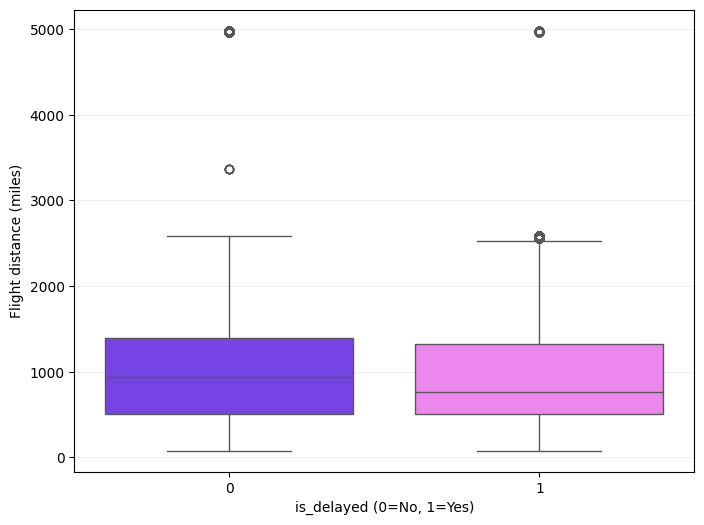

In [309]:
plt.figure(figsize=(8, 6))

colour_palette = {0: "#6c28ff", 1: "#fc76ff"}

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='distance',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('is_delayed (0=No, 1=Yes)')
plt.ylabel('Flight distance (miles)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# It seems like there isn't an obvious relationship between flight distance and delay probability

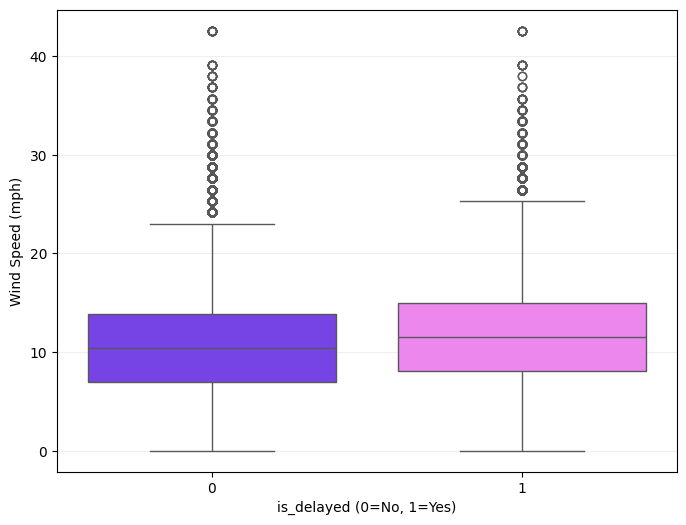

In [310]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='wind_speed',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('is_delayed (0=No, 1=Yes)')
plt.ylabel('Wind Speed (mph)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# Higher wind speeds seem to be associated with higher delay probabilities, so this may be a viable predictor

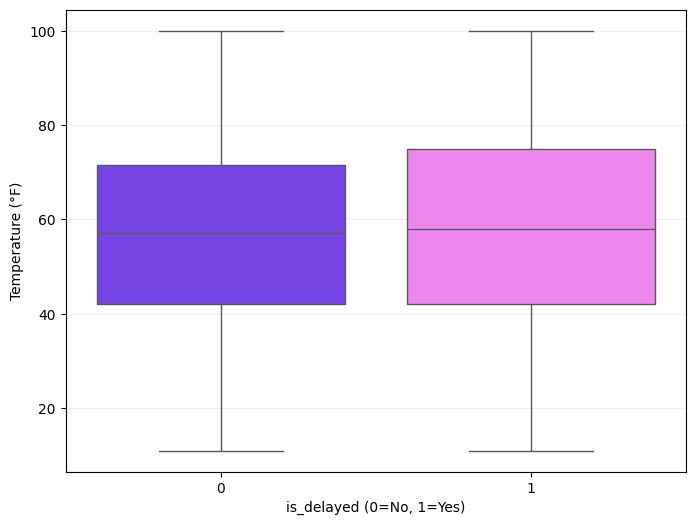

In [311]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='temp',
    hue='is_delayed',
    palette=colour_palette,
    legend=False
)

plt.xlabel('is_delayed (0=No, 1=Yes)')
plt.ylabel('Temperature (°F)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# There may be some relationship between temperature and delay probability, but this is less clear

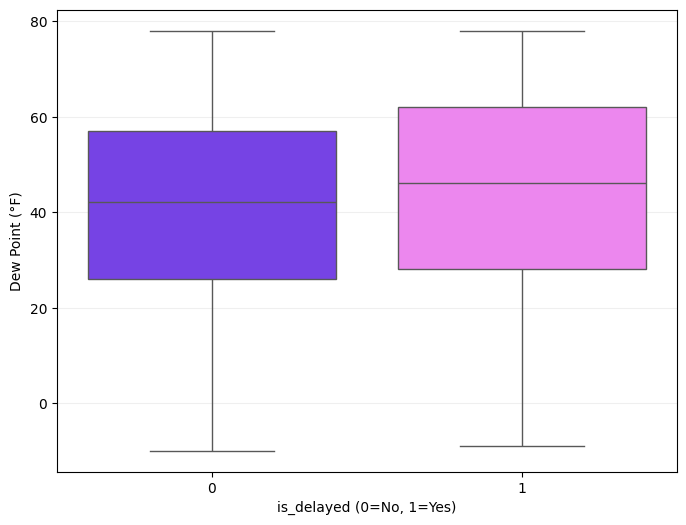

In [312]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='dewp',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('is_delayed (0=No, 1=Yes)')
plt.ylabel('Dew Point (°F)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# Higher dew points seem to have a relationship with higher delay probabilities, so this may be a viable predictor

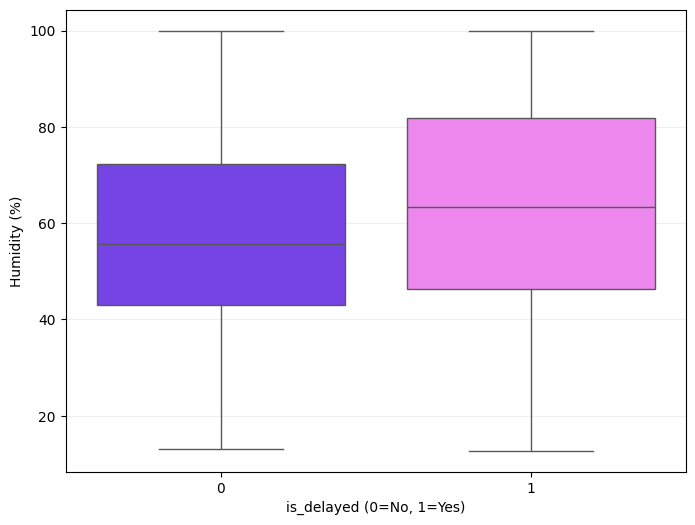

In [313]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='humid',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('is_delayed (0=No, 1=Yes)')
plt.ylabel('Humidity (%)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there's a relationship between higher humidity and higher delay probabilities, so this may also be a viable predictor

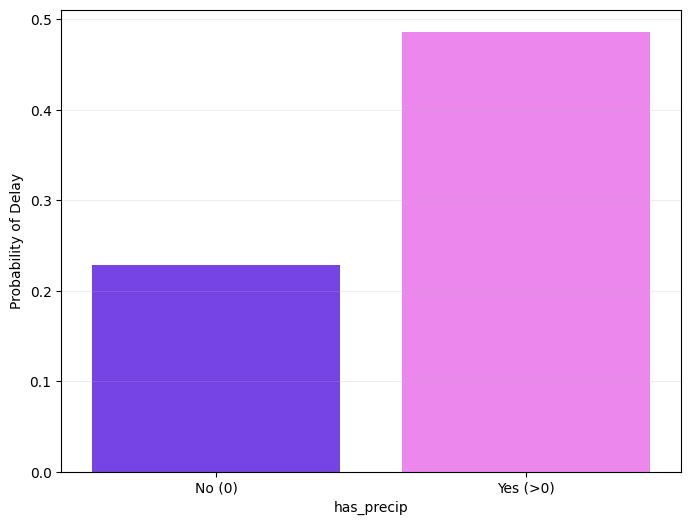

In [314]:
# Precipitation needs a different approach because of the extreme distribution shape
# We will instead create a binary label for whether there is any precipitation (>0) or not (0) and see if this has a relationship with delay probability
flights_train_copy['has_precip'] = flights_train_copy['precip'] > 0

# Calculate the average delay rate precipitation vs no precipitation
delay_stats = flights_train_copy.groupby('has_precip')['is_delayed'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(
    x=delay_stats.index,
    y=delay_stats.values,
    hue=delay_stats.index,
    palette=colour_palette,
    legend=False
)

plt.xlabel('has_precip')
plt.ylabel('Probability of Delay')
plt.xticks(ticks=[0, 1], labels=['No (0)', 'Yes (>0)'])
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there's a clear relationship between precipitation and delay probability
# So it would be worthwhile to consider changing this numerical feature into a categorical one (either binary or with different bins)
# To serve as a key predictor in the model

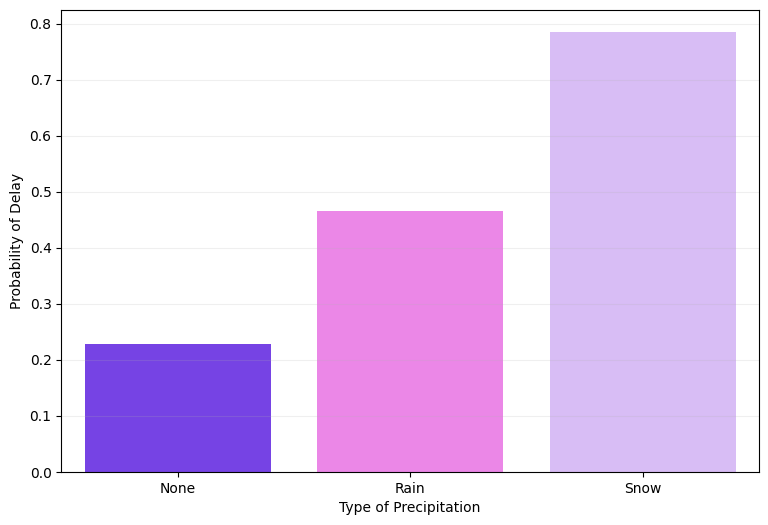

In [315]:
# Idea: what if we can split precipitation further into what type of precipitation it is (eg rain vs snow) by using the temperature feature as well?
conditions = [
    (flights_train_copy['precip'] == 0),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] > 32),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] <= 32)
]
choices = ['None', 'Rain', 'Snow']

flights_train_copy['weather_type'] = np.select(conditions, choices, default='None')

# Calculate average delay rate for each category
delay_stats = flights_train_copy.groupby('weather_type')['is_delayed'].mean().reindex(['None', 'Rain', 'Snow'])

plt.figure(figsize=(9, 6))
sns.barplot(
    x=delay_stats.index, 
    y=delay_stats.values, 
    hue=delay_stats.index,
    palette=['#6c28ff', '#fc76f7', '#d8b4fe'],
    legend=False
)

plt.xlabel('Type of Precipitation')
plt.ylabel('Probability of Delay')
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there's a stronger relationship when we break up precipitation like this instead

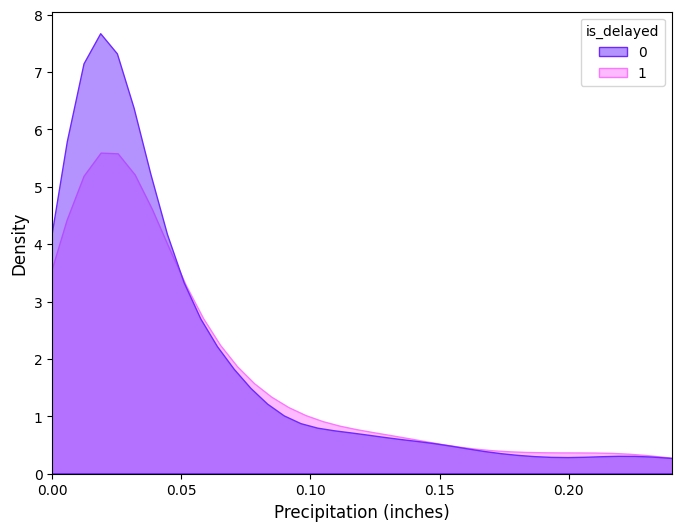

In [316]:
# To see whether it would be worthwhile to split into binary bins or more, we will visualise the distribution of precipitation
# for delayed vs non-delayed flights
plt.figure(figsize=(8, 6))

# Filter only for flights that actually had precipitation since the distribution is so skewed with a large spike at 0
rainy_flights = flights_train_copy[flights_train_copy['precip'] > 0]

sns.kdeplot(
    data=rainy_flights,
    x='precip',
    hue='is_delayed',
    fill=True, 
    palette=colour_palette,
    alpha=0.5
)

plt.xlabel('Precipitation (inches)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, rainy_flights['precip'].quantile(0.95)) # Zoom in on the most common rain amounts (up to 95th percentile)
plt.show()

# It looks like there isn't a clear relationship between the amount of precipitation and delay probability
# So it may be sufficient to just split into binary bins for whether there is precipitation or not

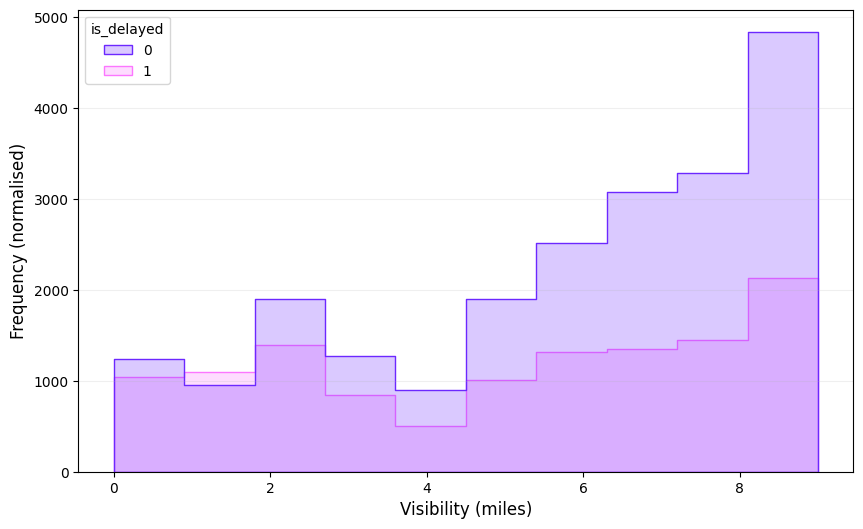

In [317]:
# Check whether there's a relationship between visibility and delay probability
plt.figure(figsize=(10, 6))

# Excluding 10 since this makes it hard to view delay/non-delay split for lower visibility levels
low_visibility_flights = flights_train_copy[flights_train_copy['visib'] < 10]

sns.histplot(
    data=low_visibility_flights,
    x='visib',
    hue='is_delayed', 
    element="step",
    palette=colour_palette, 
    bins=10,
    common_norm=False
)

plt.xlabel('Visibility (miles)', fontsize=12)
plt.ylabel('Frequency (normalised)', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there is a clear relationship between visibility and delay probability
# Lower visibility levels being associated with higher delay probabilities
# This may also benefit from being categorised into multiple bins instead of a numerical feature

### Check correlations

See if there are any highly correlated features which may be too similar. We would want to avoid having two very similar attributes in the model because it doesn't provide much additional information and risk overfitting.

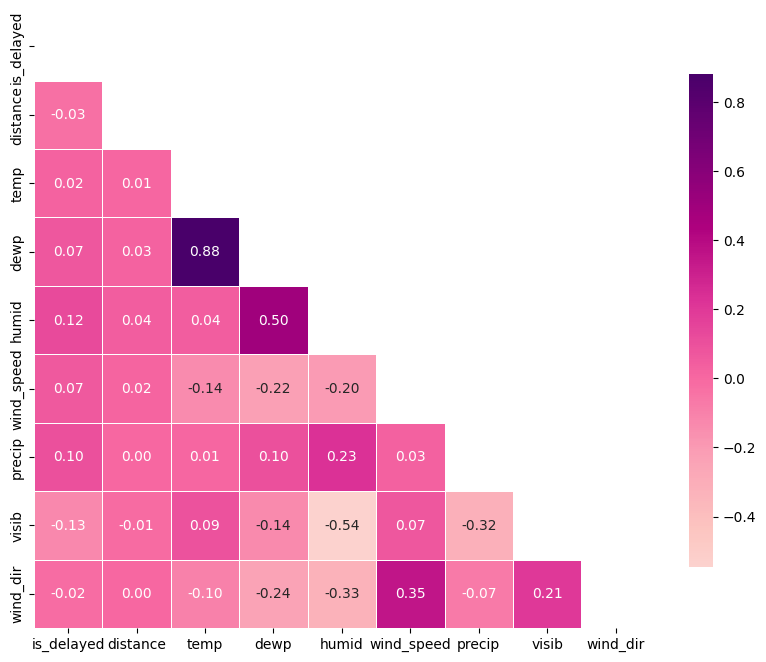

In [318]:
# Include all continuous features and the response variable (is_delayed) for the correlation matrix
numeric_vars = ['is_delayed', 'distance', 'temp', 'dewp', 'humid', 'wind_speed', 'precip', 'visib', 'wind_dir']
corr_matrix = flights_train_copy[numeric_vars].corr()

# Can just take the lower triangle of the correlation matrix to avoid redundancy since it's symmetric
# https://numpy.org/doc/stable/reference/generated/numpy.triu.html
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# We can use a heatmap to easily visualise the correlations between features
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdPu',
    center=0,
    square=True,
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.show()

# dewp and temp have a high correlation, so we will drop temp (since it has a lower correlation with is_delayed) to avoid multicollinearity
# visib and humid also have a high correlation, but we will keep both of these since they have a higher correlation with is_delayed
# We could also keep wind_speed and precip, bearing in mind that if they are categories they may have a strong relationship with is_delayed

### 4. Revised Data Cleaning
* Remove rows with lots of missing data
* Remove columns with lots of missing data
* Fill in values based off insights from data exploration

In [319]:
# Reminder of feature which have null values
flights_train_copy.info()

<class 'pandas.DataFrame'>
Index: 209500 entries, 59674 to 186079
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   year            209500 non-null  int64   
 1   month           209500 non-null  category
 2   day             209500 non-null  int64   
 3   dep_time        209500 non-null  float64 
 4   sched_dep_time  209500 non-null  int64   
 5   dep_delay       209500 non-null  float64 
 6   arr_time        209500 non-null  float64 
 7   sched_arr_time  209500 non-null  int64   
 8   arr_delay       209500 non-null  float64 
 9   carrier         209500 non-null  category
 10  flight          209500 non-null  int64   
 11  tailnum         209500 non-null  str     
 12  origin          209500 non-null  category
 13  dest            209500 non-null  category
 14  air_time        209500 non-null  float64 
 15  distance        209500 non-null  int64   
 16  hour            209500 non-null  category
 17  min

In [320]:
# temp, dewp, humid, wind_dir, wind_speed, precip, and visib have some null values
# wind_dir we will drop now since it has a low correlation with the response and no clear distribution
# we will impute the others

# Drop wind_dir from the training set
flights_train_copy = flights_train_copy.drop(columns=['wind_dir'])

# temp, dewp, humid, wind_speed, and distance will be imputed with the median
median_features = ['temp', 'dewp', 'humid', 'wind_speed', 'distance']

# precip and visib will be imputed with the mode
mode_features = ['precip', 'visib']

median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

flights_train_copy[median_features] = median_imputer.fit_transform(flights_train_copy[median_features])
flights_train_copy[mode_features] = mode_imputer.fit_transform(flights_train_copy[mode_features])

# Sanity check there are no more null values
flights_train_copy.isna().sum(axis=0).to_frame(name='# of Missing Values')

,# of Missing Values
year,0
month,0
day,0
dep_time,0
sched_dep_time,0
dep_delay,0
arr_time,0
sched_arr_time,0
arr_delay,0
carrier,0


### 5. (Exploring) Feature Engineering

Would it be useful to change any numerical attributes into categorical ones?

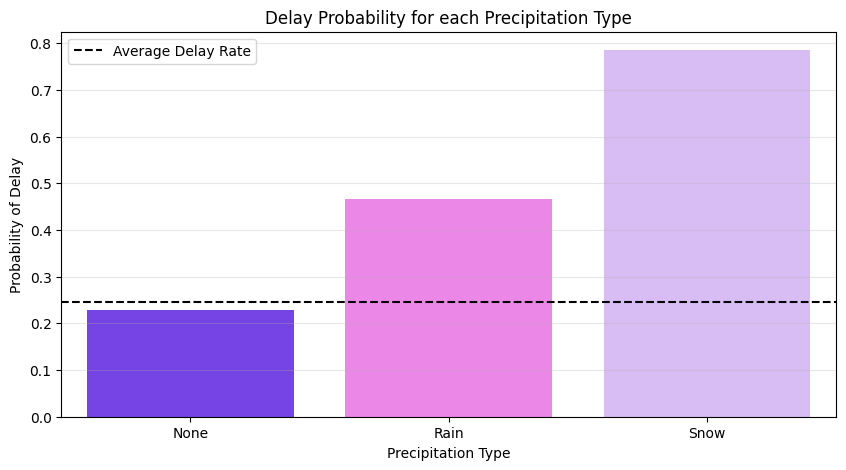

In [321]:
# Make a new feature precip_cat (categorical) feature with "None", "Rain" and "Snow" using temperature and precip
conditions = [
    (flights_train_copy['precip'] == 0),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] > 32),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] <= 32)
]
choices = ['None', 'Rain', 'Snow']

flights_train_copy['precip_cat'] = np.select(conditions, choices, default='None')
flights_train_copy['precip_cat'] = flights_train_copy['precip_cat'].astype('category')

# Plot the relationship between has_precip and is_delayed to confirm the relationship after categorisation
plt.figure(figsize=(10, 5))
vis_rel = flights_train_copy.groupby('precip_cat')['is_delayed'].mean().reindex(['None', 'Rain', 'Snow'])

sns.barplot(
    x=vis_rel.index, 
    y=vis_rel.values, 
    hue=vis_rel.index,
    palette=['#6c28ff', '#fc76f7', '#d8b4fe']
)

plt.title('Delay Probability for each Precipitation Type')
plt.ylabel('Probability of Delay')
plt.xlabel('Precipitation Type')
plt.axhline(flights_train_copy['is_delayed'].mean(), color="#000000", linestyle='--', label='Average Delay Rate')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

# This looks like it would be a valuable transformation to make

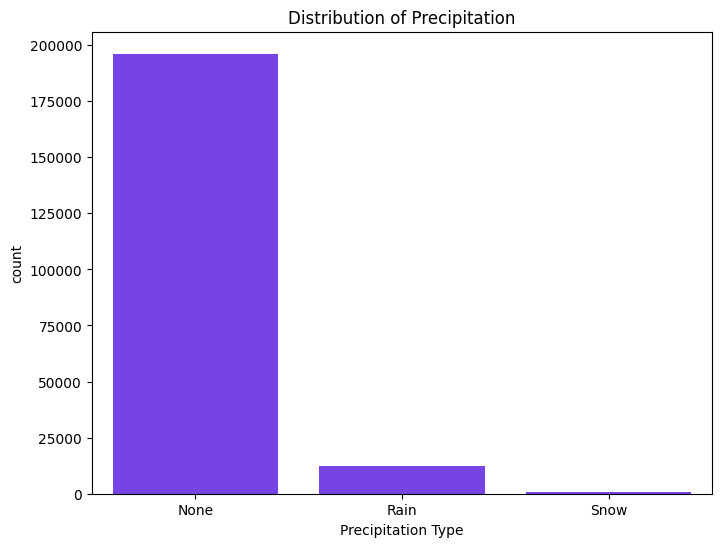

In [322]:
# Look at the distribution of precipitation type
plt.figure(figsize=(8, 6))

sns.countplot(
    data=flights_train_copy,
    x='precip_cat',
    color='#6c28ff',
    legend=False
)

plt.title('Distribution of Precipitation')
plt.xlabel('Precipitation Type')
plt.show()

# We would impute with 'None' here
# While the precipitation categories would be a great predictor, the distribution is very imbalanced so it won't have that much influence

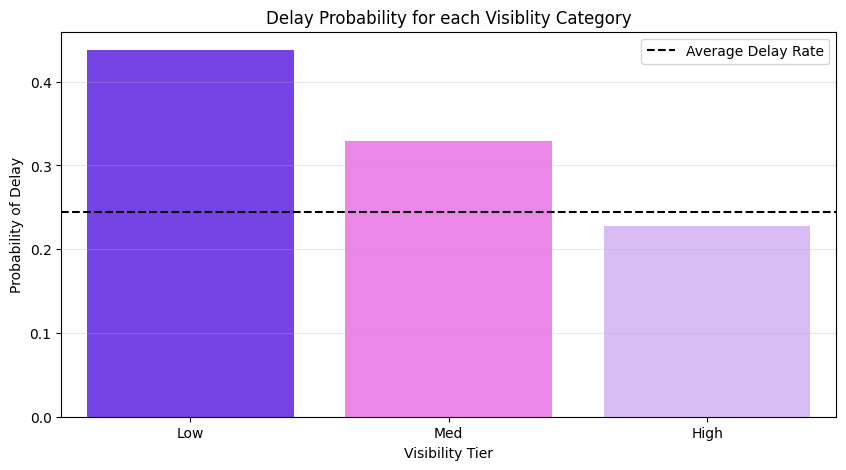

In [323]:
# Change visib into a categorical feature with 3 bins: low, medium, and high visibility
bins = [-1, 4, 7, 10]
labels = ['Low', 'Med', 'High']
flights_train_copy['visib_cat'] = pd.cut(flights_train_copy['visib'], bins=bins, labels=labels)

# Plot the relationship between visib_cat and is_delayed to confirm the relationship after categorisation
plt.figure(figsize=(10, 5))

vis_rel = flights_train_copy.groupby('visib_cat')['is_delayed'].mean().reindex(['Low', 'Med', 'High'])

sns.barplot(
    x=vis_rel.index,
    y=vis_rel.values,
    hue=vis_rel.index,
    palette=['#6c28ff', '#fc76f7', '#d8b4fe']
)

plt.title('Delay Probability for each Visiblity Category')
plt.ylabel('Probability of Delay')
plt.xlabel('Visibility Tier')
plt.axhline(flights_train_copy['is_delayed'].mean(), color="#000000", linestyle='--', label='Average Delay Rate')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

# This also looks like it would be a valuable transformation to make

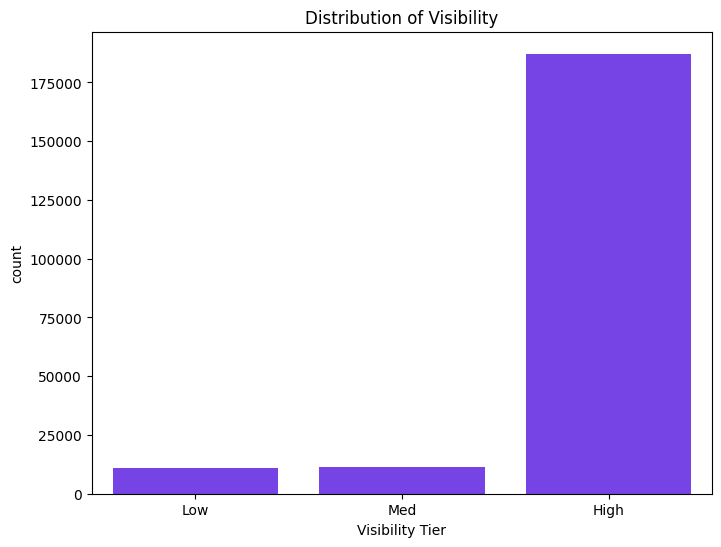

In [324]:
# Look at distribution of visibility tier
plt.figure(figsize=(8, 6))
sns.countplot(data=flights_train_copy, x='visib_cat', color='#6c28ff')

plt.title('Distribution of Visibility')
plt.xlabel('Visibility Tier')
plt.show()

# We would impute with 'High' visibility here
# Like precipitation, the visibility categories would be a great predictor but the distribution is very imbalanced so it won't have that much influence

## Preparing a Pipeline
Based off of what we now know from the data we need to build a pipeline which:
* Selects which features to keep
* Cleans and imputes the data, considering NA values
* Performs any suitable feature engineering
* Prepares the data for interpretation by a ML model (one_hot and scaling)

`precip` and `visib` will be changed into categorical variables based off of the data exploration. `precip` will be changed into a binary label `has_precip` and `visib` will be changed into low/med/high bins since there's a more varied distribution.

The following features will be used based off of their perceived relationship and/or correlation with the response, `is_delayed`:
* month
* carrier
* origin
* hour
* dewp
* humid
* has_precip (feature engineered from precip)
* visib_cat (feature engineered from visib)

In [325]:
def transformer_categorical(X):
    # Change precip into a categorical feature with "None", "Rain", and "Snow" using temperature and precip
    conditions = [
        (X['precip'] == 0),
        (X['precip'] > 0) & (X['temp'] > 32),
        (X['precip'] > 0) & (X['temp'] <= 32)
    ]
    choices = ['None', 'Rain', 'Snow']
    
    X['weather_conditions'] = np.select(conditions, choices, default='None')
    X['weather_conditions'] = X['weather_conditions'].astype('category')

    # Change visib into a categorical feature with 3 bins: low, medium, and high visibility
    bins = [-1, 4, 7, 10]
    labels = ['Low', 'Med', 'High']
    X['visib_cat'] = pd.cut(X['visib'], bins=bins, labels=labels)   

    # Drop the original precip, visib, and temp columns since they've been transformed
    X = X.drop(columns=['precip', 'visib', 'temp'])

    return X

def clean_and_prep(X, features_selected, median_imputer, mode_imputer):
    X = X.copy() # Safety measure

    # Impute missing values (note transform only and not fit since we don't want to fit the test set)
    X[median_features] = median_imputer.transform(X[median_features])
    X[mode_features] = mode_imputer.transform(X[mode_features])

    # Transform numerical attributes (precip and visib) into categorical (has_precip and visib_cat)
    X = transformer_categorical(X)

    # Filter features 
    X = X[features_selected]

    return X

In [326]:
# temp, dewp, humid, wind_speed, and distance will be imputed with the median
median_features = ['temp', 'dewp', 'humid', 'wind_speed', 'distance']
# precip and visib will be imputed with the mode
mode_features = ['precip', 'visib']

# Define and fit the imputers on the training data only
# https://www.youtube.com/watch?v=6as06vtXNL8
median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

# Fit the imputers on the training data (and NOT the validation or test data to avoid data leakage)
median_imputer.fit(flights_train_raw[median_features])
mode_imputer.fit(flights_train_raw[mode_features])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [ ]:
# Features selected based on the exploratory data analysis

# Distance and humid haven't been selected because of their low correlation with the response and weak data patterns
# We could include them but don't want to risk overfitting, so will leave them out for now
features_selected = ["month", "carrier", "origin", "hour", "wind_speed", "visib_cat", "dewp", "weather_conditions"]

# Extract the response variable from the training, validation, and test sets before running the pipeline
train_labels = flights_train_raw['is_delayed']
validation_labels = flights_validation_raw['is_delayed']
test_labels = flights_test_raw['is_delayed']

# Clean and prepare the raw training data (NOT the copy used for exploration)
cleaned_training_data = clean_and_prep(flights_train_raw, features_selected, median_imputer, mode_imputer)
cleaned_validation_data = clean_and_prep(flights_validation_raw, features_selected, median_imputer, mode_imputer)
cleaned_test_data = clean_and_prep(flights_test_raw, features_selected, median_imputer, mode_imputer)

# Define the numerical and categorical attributes
numerical_attributes = ["dewp", "wind_speed"]
categorical_attributes = ["month", "carrier", "origin", "hour", "visib_cat", "weather_conditions"]

# Define the pipeline
full_pipeline = ColumnTransformer([
    ("numerical", StandardScaler(), numerical_attributes),
    ("categorical", OneHotEncoder(sparse_output=False), categorical_attributes),
])
full_pipeline.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [328]:
# Run the pipeline
prepared_training_data = full_pipeline.fit_transform(cleaned_training_data)
prepared_validation_data = full_pipeline.transform(cleaned_validation_data)
prepared_test_data = full_pipeline.transform(cleaned_test_data)

## Building Classification Models

We will build and train 4 different machine learning models on the training set and then pick the best one using the validation set. The 4 classification models we will train are:
* Logistic Regression
* Stochastic Gradient Descent Classifier
* Random Forest Classifier
* Histogram-based Gradient Boosting Classifier

### Logistic Regression

In [329]:
# We will keep the default scikitlearn parameters and fine tune one later

# Logistic Regression 
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
logistic_regression_model = LogisticRegression(
    class_weight='balanced', # Account for the imbalanced dataset
    max_iter=100,
    tol=0.001,
    random_state=42
)

# Fit the model on the training set
logistic_regression_model.fit(prepared_training_data, train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

Run the model on the training and validation set.

In [330]:
# Training Set
lr_preds_train = logistic_regression_model.predict(prepared_training_data)
lr_probs_train = logistic_regression_model.predict_proba(prepared_training_data)[:, 1]

# Validation Set
lr_preds_val = logistic_regression_model.predict(prepared_validation_data)
lr_probs_val = logistic_regression_model.predict_proba(prepared_validation_data)[:, 1]

Examine the model's performance on the training set vs validation set.
- Check for under/overfitting

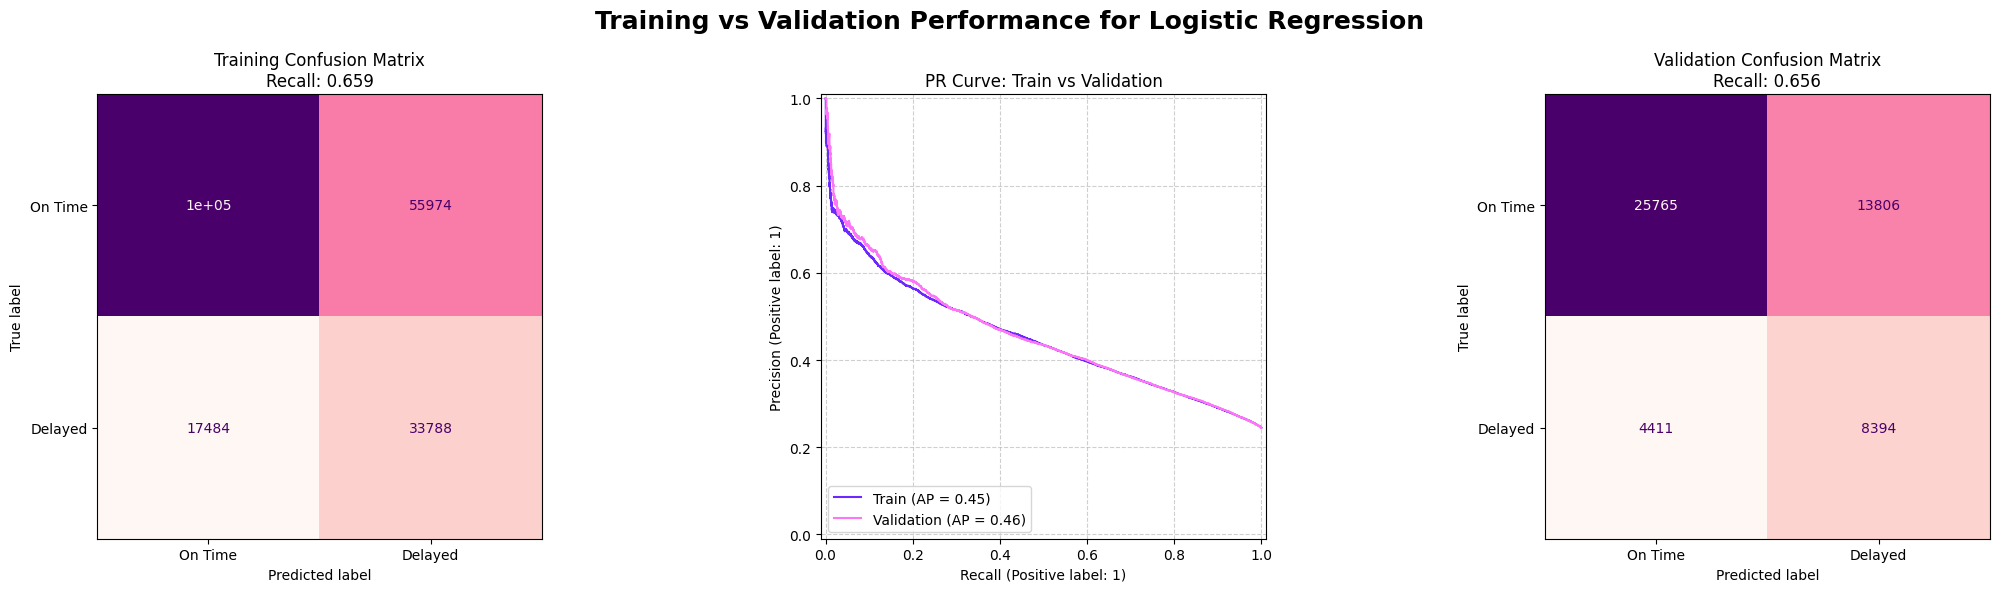

In [331]:
# Create a plot of the 2 confusion matrices and a PR curve
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Training set confusion matrix
lr_cm_train = confusion_matrix(train_labels, lr_preds_train)
lr_disp_train = ConfusionMatrixDisplay(confusion_matrix=lr_cm_train, display_labels=['On Time', 'Delayed'])
lr_disp_train.plot(ax=axes[0], cmap='RdPu', colorbar=False)
axes[0].set_title(f"Training Confusion Matrix\nRecall: {recall_score(train_labels, lr_preds_train):.3f}", fontsize=12)


# PR Curve (train & validation)
PrecisionRecallDisplay.from_predictions( # Training line
    train_labels, lr_probs_train, name="Train", ax=axes[1], color='#6c28ff'
)
PrecisionRecallDisplay.from_predictions( # Validation Line
    validation_labels, lr_probs_val, name="Validation", ax=axes[1], color='#fc76f7'
)
axes[1].set_title("PR Curve: Train vs Validation", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)


# Validation set confusion matrix
lr_cm_val = confusion_matrix(validation_labels, lr_preds_val)
lr_disp_val = ConfusionMatrixDisplay(confusion_matrix=lr_cm_val, display_labels=['On Time', 'Delayed'])
lr_disp_val.plot(ax=axes[2], cmap='RdPu', colorbar=False)
axes[2].set_title(f"Validation Confusion Matrix\nRecall: {recall_score(validation_labels, lr_preds_val):.3f}", fontsize=12)

plt.suptitle("Training vs Validation Performance for Logistic Regression", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Stochastic Gradient Descent Classifier

In [332]:
# Stochastic gradient descent classifier
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
sgd_model = SGDClassifier(
    loss='log_loss', # Using logistic regression
    class_weight='balanced', 
    max_iter=100,
    random_state=42
)

# Fit the model on the training set
sgd_model.fit(prepared_training_data, train_labels)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",100
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Run the model on the training and validation set.

In [333]:
# Training Set
sgd_preds_train = sgd_model.predict(prepared_training_data)
sgd_probs_train = sgd_model.predict_proba(prepared_training_data)[:, 1]

# Validation Set
sgd_preds_val = sgd_model.predict(prepared_validation_data)
sgd_probs_val = sgd_model.predict_proba(prepared_validation_data)[:, 1]

Examine the model's performance on the training set vs validation set.
- Check for under/overfitting

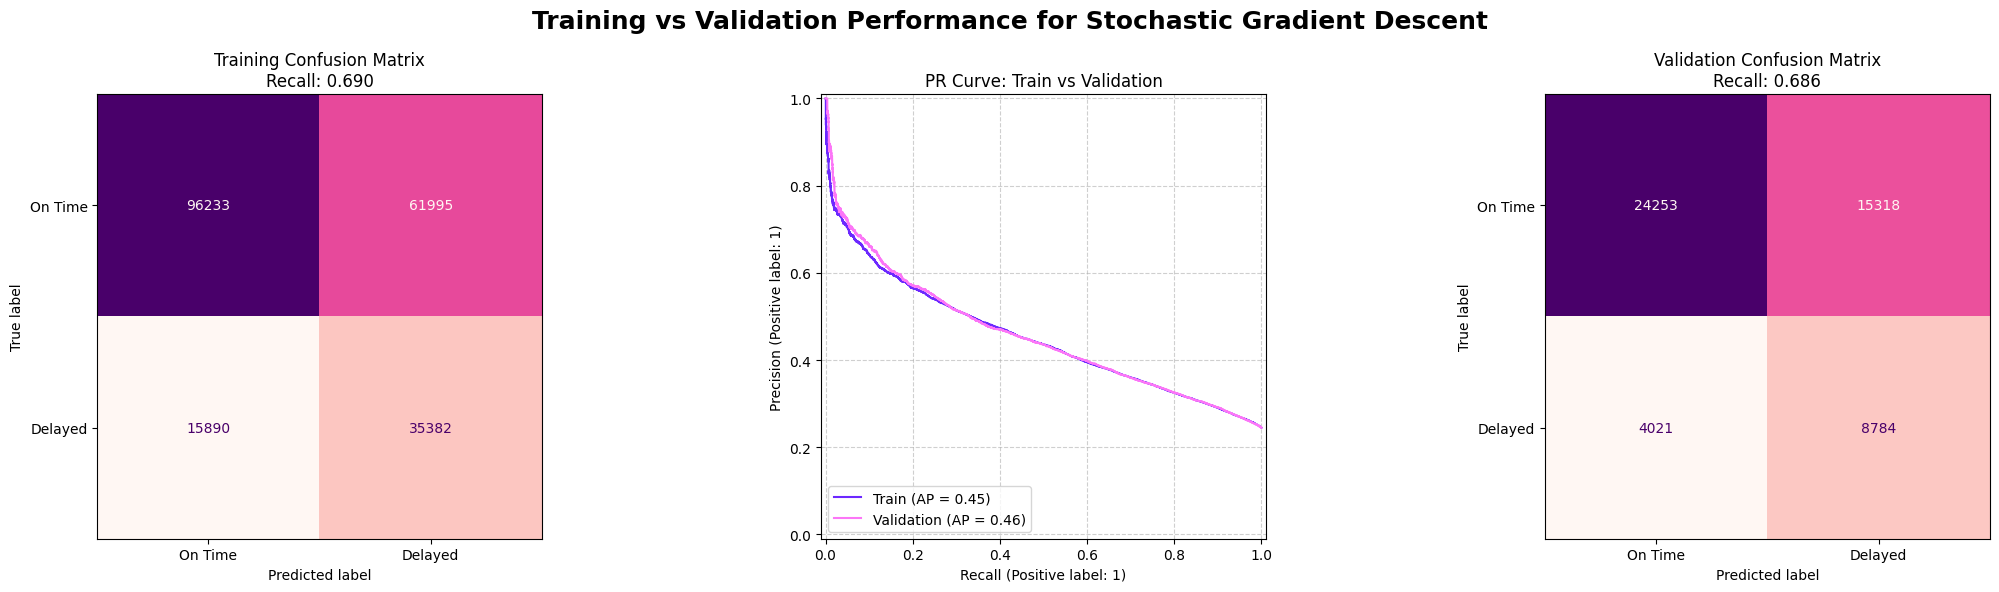

In [334]:
# Create a plot of the 2 confusion matrices and a PR curve
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Training set confusion matrix
sgd_cm_train = confusion_matrix(train_labels, sgd_preds_train)
sgd_disp_train = ConfusionMatrixDisplay(confusion_matrix=sgd_cm_train, display_labels=['On Time', 'Delayed'])
sgd_disp_train.plot(ax=axes[0], cmap='RdPu', colorbar=False)
axes[0].set_title(f"Training Confusion Matrix\nRecall: {recall_score(train_labels, sgd_preds_train):.3f}", fontsize=12)


# PR Curve (train & validation)
PrecisionRecallDisplay.from_predictions( # Training line
    train_labels, sgd_probs_train, name="Train", ax=axes[1], color='#6c28ff'
)
PrecisionRecallDisplay.from_predictions( # Validation Line
    validation_labels, sgd_probs_val, name="Validation", ax=axes[1], color='#fc76f7'
)
axes[1].set_title("PR Curve: Train vs Validation", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)


# Validation set confusion matrix
sgd_cm_val = confusion_matrix(validation_labels, sgd_preds_val)
sgd_disp_val = ConfusionMatrixDisplay(confusion_matrix=sgd_cm_val, display_labels=['On Time', 'Delayed'])
sgd_disp_val.plot(ax=axes[2], cmap='RdPu', colorbar=False)
axes[2].set_title(f"Validation Confusion Matrix\nRecall: {recall_score(validation_labels, sgd_preds_val):.3f}", fontsize=12)

plt.suptitle("Training vs Validation Performance for Stochastic Gradient Descent", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Random Forest Classifier

In [335]:
# Random Forest classifier
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
random_forest_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1 # Use all cores to speed up training since this is a computationally expensive model
)

# Fit the model on the training set
random_forest_model.fit(prepared_training_data, train_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Run the model on the training and validation set.

In [336]:
# Training Set
rf_preds_train = random_forest_model.predict(prepared_training_data)
rf_probs_train = random_forest_model.predict_proba(prepared_training_data)[:, 1]

# Validation Set
rf_preds_val = random_forest_model.predict(prepared_validation_data)
rf_probs_val = random_forest_model.predict_proba(prepared_validation_data)[:, 1]

Examine the model's performance on the training set vs validation set.
- Check for under/overfitting

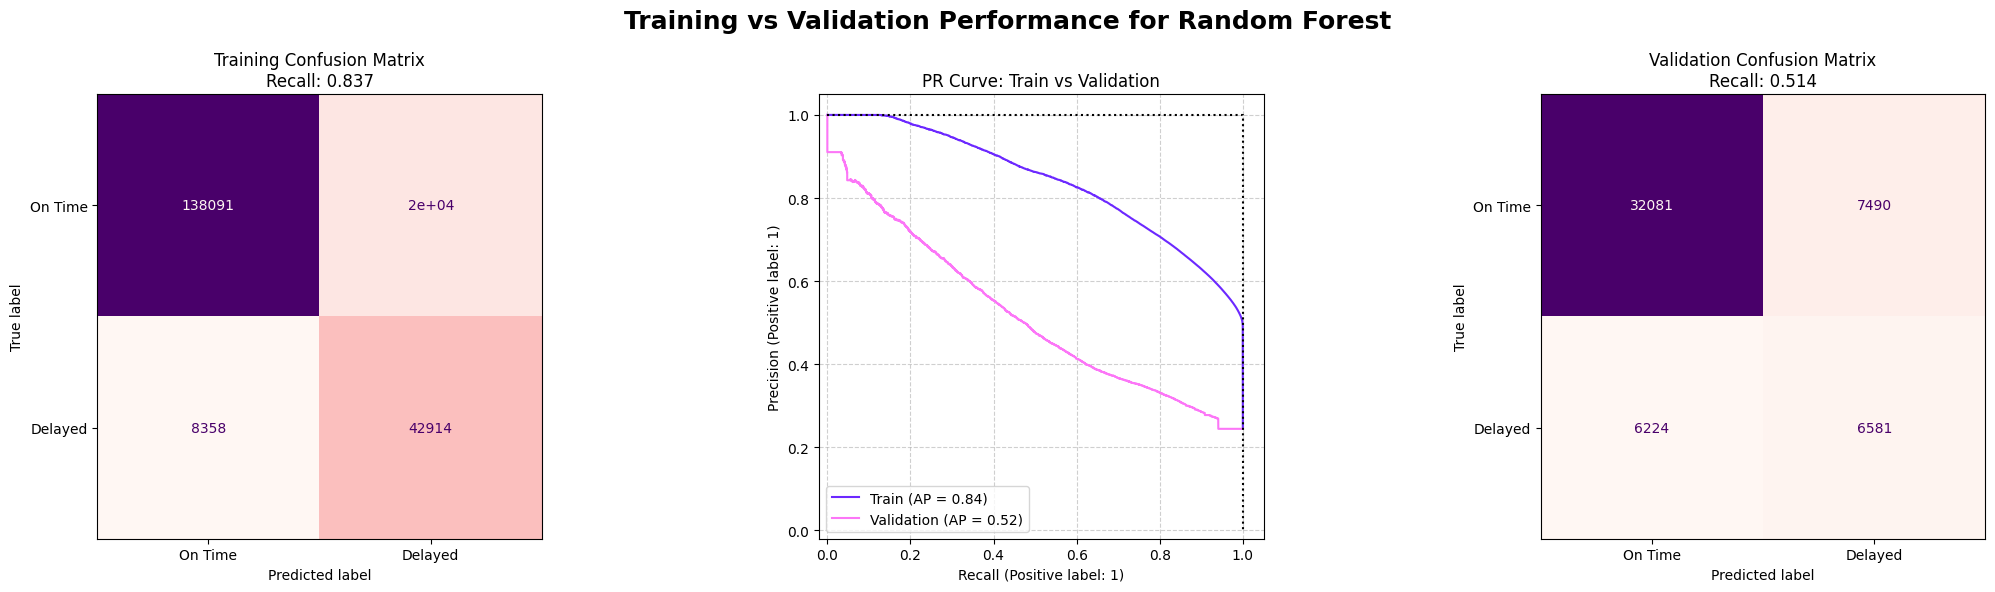

In [337]:
# Create a plot of the 2 confusion matrices and a PR curve
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Training set confusion matrix
rf_cm_train = confusion_matrix(train_labels, rf_preds_train)
rf_disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=['On Time', 'Delayed'])
rf_disp_train.plot(ax=axes[0], cmap='RdPu', colorbar=False)
axes[0].set_title(f"Training Confusion Matrix\nRecall: {recall_score(train_labels, rf_preds_train):.3f}", fontsize=12)


# PR Curve (train & validation)
PrecisionRecallDisplay.from_predictions( # Training line
    train_labels, rf_probs_train, name="Train", ax=axes[1], color='#6c28ff'
)
PrecisionRecallDisplay.from_predictions( # Validation Line
    validation_labels, rf_probs_val, name="Validation", ax=axes[1], color='#fc76f7'
)
axes[1].plot([0, 1, 1], [1, 1, 0], color='black', linestyle=':', label='Perfect Model', alpha=1) # Draw a perfect line for comparison
axes[1].set_title("PR Curve: Train vs Validation", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)


# Validation set confusion matrix
rf_cm_val = confusion_matrix(validation_labels, rf_preds_val)
rf_disp_val = ConfusionMatrixDisplay(confusion_matrix=rf_cm_val, display_labels=['On Time', 'Delayed'])
rf_disp_val.plot(ax=axes[2], cmap='RdPu', colorbar=False)
axes[2].set_title(f"Validation Confusion Matrix\nRecall: {recall_score(validation_labels, rf_preds_val):.3f}", fontsize=12)

plt.suptitle("Training vs Validation Performance for Random Forest", fontsize=18, fontweight='bold')
axes[1].set_xlim([-0.02, 1.05]) # Slight padding so the perfect line isn't cut off
axes[1].set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

# It looks like random forest is overfitting slightly on the training set
# Its recall is high on the training and much lower on the validation
# This is also shown by the purple train line on the PR curve being much closer to a perfect classifier

# No other models so far seem to have this issue
# After some reading, the default hyperparameters: max_depth=None and min_samples_leaf=1 may be causing this issue
# max_depth=None means each tree can tree to an unbounded depth, effectively just memorising the training data
# min_samples_leaf=1 means you only need 1 observation (flight) to make a rule, making the memorisation much more specific

In [338]:
# Let's see what happens if we change these (although we won't be selecting RF as the model to fine tune)
# https://www.baeldung.com/cs/random-forest-overfitting-fix
new_random_forest_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=10, # Arbitrary - the max depth (and so specificity) a tree can have is 10
    min_samples_leaf=50, # Arbitrary - we now need 50 observations/flights to declare a new rule
    random_state=42,
    n_jobs=-1
)

new_random_forest_model.fit(prepared_training_data, train_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [339]:
# Training Set
new_rf_preds_train = new_random_forest_model.predict(prepared_training_data)
new_rf_probs_train = new_random_forest_model.predict_proba(prepared_training_data)[:, 1]

# Validation Set
new_rf_preds_val = new_random_forest_model.predict(prepared_validation_data)
new_rf_probs_val = new_random_forest_model.predict_proba(prepared_validation_data)[:, 1]

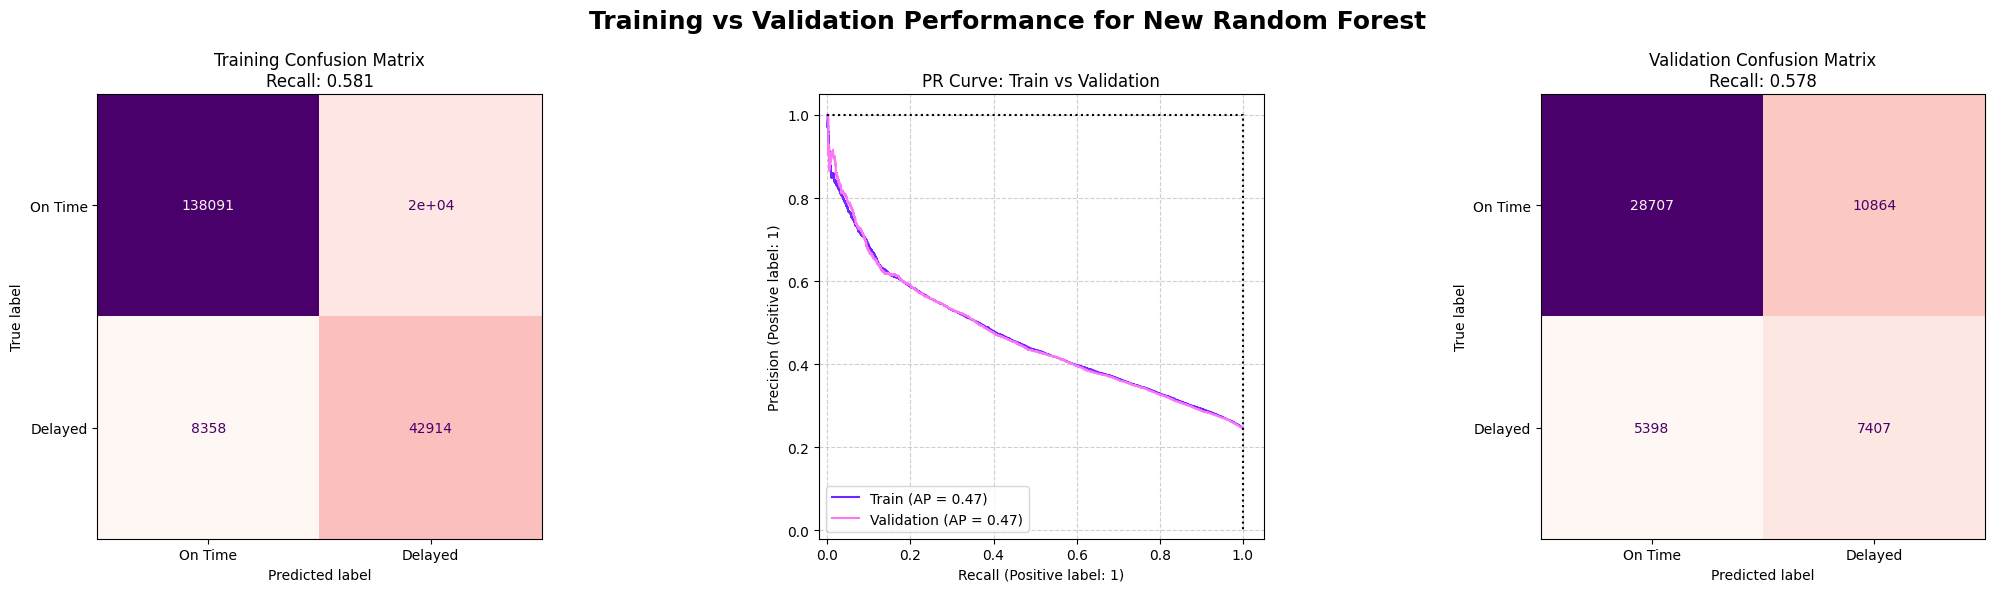

In [340]:
# Create a plot of the 2 confusion matrices and a PR curve
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Training set confusion matrix
new_rf_cm_train = confusion_matrix(train_labels, new_rf_preds_train)
new_rf_disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=['On Time', 'Delayed'])
new_rf_disp_train.plot(ax=axes[0], cmap='RdPu', colorbar=False)
axes[0].set_title(f"Training Confusion Matrix\nRecall: {recall_score(train_labels, new_rf_preds_train):.3f}", fontsize=12)


# PR Curve (train & validation)
PrecisionRecallDisplay.from_predictions( # Training line
    train_labels, new_rf_probs_train, name="Train", ax=axes[1], color='#6c28ff'
)
PrecisionRecallDisplay.from_predictions( # Validation Line
    validation_labels, new_rf_probs_val, name="Validation", ax=axes[1], color='#fc76f7'
)
axes[1].plot([0, 1, 1], [1, 1, 0], color='black', linestyle=':', label='Perfect Model', alpha=1) # Draw a perfect line for comparison
axes[1].set_title("PR Curve: Train vs Validation", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)


# Validation set confusion matrix
new_rf_cm_val = confusion_matrix(validation_labels, new_rf_preds_val)
new_rf_disp_val = ConfusionMatrixDisplay(confusion_matrix=new_rf_cm_val, display_labels=['On Time', 'Delayed'])
new_rf_disp_val.plot(ax=axes[2], cmap='RdPu', colorbar=False)
axes[2].set_title(f"Validation Confusion Matrix\nRecall: {recall_score(validation_labels, new_rf_preds_val):.3f}", fontsize=12)

plt.suptitle("Training vs Validation Performance for New Random Forest", fontsize=18, fontweight='bold')
axes[1].set_xlim([-0.02, 1.05]) # Slight padding so the perfect line isn't cut off
axes[1].set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

This seems to have reduced the overfitting, but we won't be selecting random forest for our model to properly fine tune because we don't want to risk overfitting in our model at all.

### Histogram Gradient Boosting Classifier

In [349]:
# Histogram Gradient Boosting classifier
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html#sklearn.ensemble.HistGradientBoostingClassifier
hist_gradient_boosting_model = HistGradientBoostingClassifier(
    loss='log_loss', # Using logistic regression
    class_weight='balanced',
    learning_rate=0.1,
    max_iter=100,
    max_leaf_nodes=31,
    max_depth=None,
    min_samples_leaf=20,
    random_state=42,
    early_stopping=True
)

# Fit the model on the training set
hist_gradient_boosting_model.fit(prepared_training_data, train_labels)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

Run the model on the training and validation set.

In [350]:
# Training Set
hgb_preds_train = hist_gradient_boosting_model.predict(prepared_training_data)
hgb_probs_train = hist_gradient_boosting_model.predict_proba(prepared_training_data)[:, 1]

# Validation Set
hgb_preds_val = hist_gradient_boosting_model.predict(prepared_validation_data)
hgb_probs_val = hist_gradient_boosting_model.predict_proba(prepared_validation_data)[:, 1]

Run the model on the training and validation set.
Examine the model's performance on the training set vs validation set.
- Check for under/overfitting

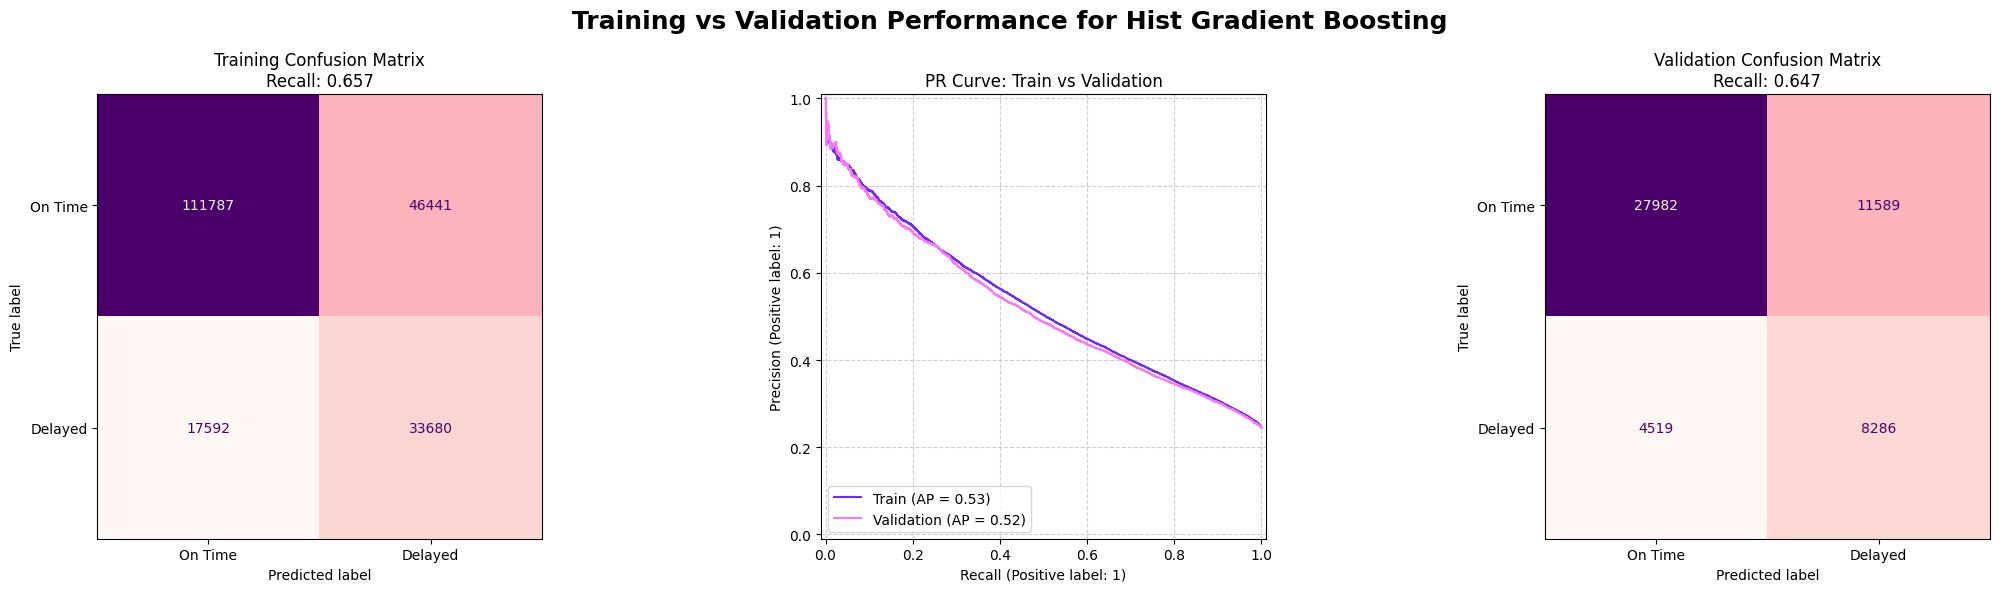

In [351]:
# Create a plot of the 2 confusion matrices and a PR curve
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Training set confusion matrix
hgb_cm_train = confusion_matrix(train_labels, hgb_preds_train)
hgb_disp_train = ConfusionMatrixDisplay(confusion_matrix=hgb_cm_train, display_labels=['On Time', 'Delayed'])
hgb_disp_train.plot(ax=axes[0], cmap='RdPu', colorbar=False)
axes[0].set_title(f"Training Confusion Matrix\nRecall: {recall_score(train_labels, hgb_preds_train):.3f}", fontsize=12)


# PR Curve (train & validation)
PrecisionRecallDisplay.from_predictions( # Training line
    train_labels, hgb_probs_train, name="Train", ax=axes[1], color='#6c28ff'
)
PrecisionRecallDisplay.from_predictions( # Validation Line
    validation_labels, hgb_probs_val, name="Validation", ax=axes[1], color='#fc76f7'
)
axes[1].set_title("PR Curve: Train vs Validation", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)


# Validation set confusion matrix
hgb_cm_val = confusion_matrix(validation_labels, hgb_preds_val)
hgb_disp_val = ConfusionMatrixDisplay(confusion_matrix=hgb_cm_val, display_labels=['On Time', 'Delayed'])
hgb_disp_val.plot(ax=axes[2], cmap='RdPu', colorbar=False)
axes[2].set_title(f"Validation Confusion Matrix\nRecall: {recall_score(validation_labels, hgb_preds_val):.3f}", fontsize=12)

plt.suptitle("Training vs Validation Performance for Hist Gradient Boosting", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Comparing all models

Look at how all models performed on the **training data** side by side.

In [352]:
training_model_results = {}

training_model_results["LR"] = {
        'preds': lr_preds_train,
        'probs': lr_probs_train,
        'recall': recall_score(train_labels, lr_preds_train),
        'f1': f1_score(train_labels, lr_preds_train)
    }

training_model_results["SGD"] = {
        'preds': sgd_preds_train,
        'probs': sgd_probs_train,
        'recall': recall_score(train_labels, sgd_preds_train),
        'f1': f1_score(train_labels, sgd_preds_train)
    }

training_model_results["(Tuned) RF"] = {
        'preds': new_rf_preds_train,
        'probs': new_rf_probs_train,
        'recall': recall_score(train_labels, new_rf_preds_train),
        'f1': f1_score(train_labels, new_rf_preds_train)
    }

training_model_results["HGB"] = {
        'preds': hgb_preds_train,
        'probs': hgb_probs_train,
        'recall': recall_score(train_labels, hgb_preds_train),
        'f1': f1_score(train_labels, hgb_preds_train)
    }

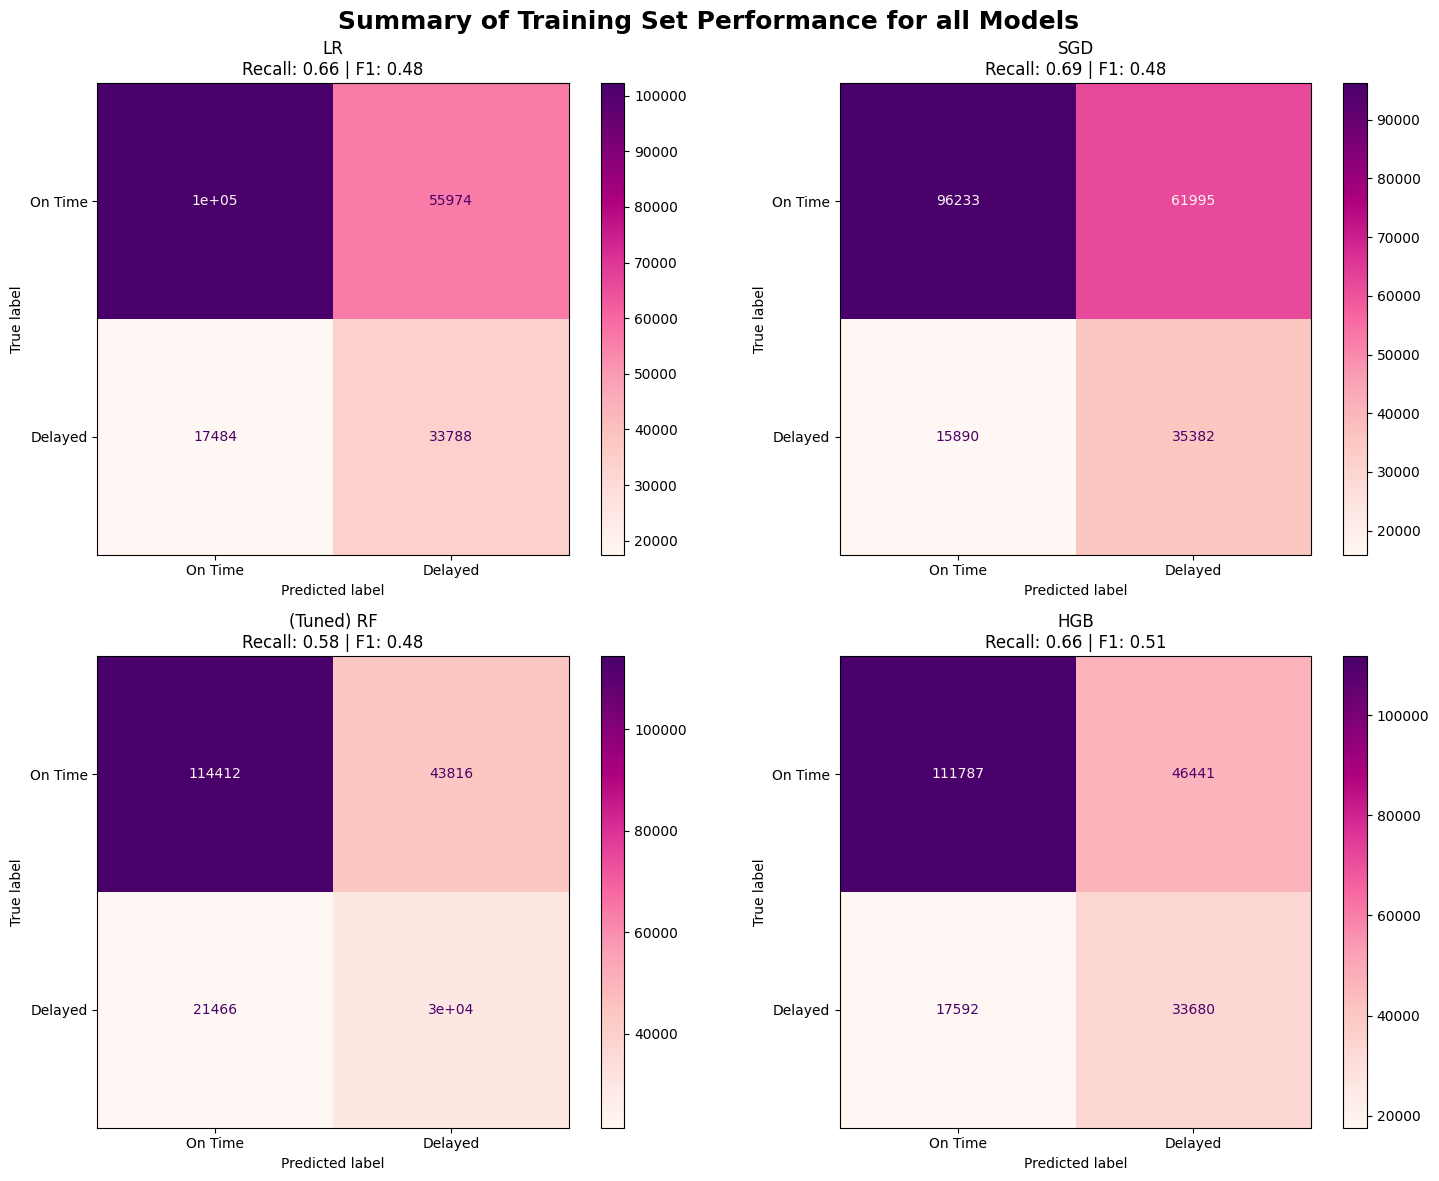

In [353]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(training_model_results.items()):
    cm = confusion_matrix(train_labels, data['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
    disp.plot(ax=axes[i], cmap='RdPu', colorbar=True)
    axes[i].set_title(f"{name}\nRecall: {data['recall']:.2f} | F1: {data['f1']:.2f}")

plt.suptitle("Summary of Training Set Performance for all Models", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# We are prioritising recall over precision (the precision/recall trade-off) because over-predicting delays is better than missing real delays
# This is because it would be a precautionary measure to overprepare for flight delays, but too costly to miss multiple delays
# SGD has the best recall overall (0.69) but its F1 score is low indicating a very low precision

# HGB and LR have the same recall, but HGB has a better F1 score (0.51), so this looks like the most promising model which balances precision/recall while favouring recall

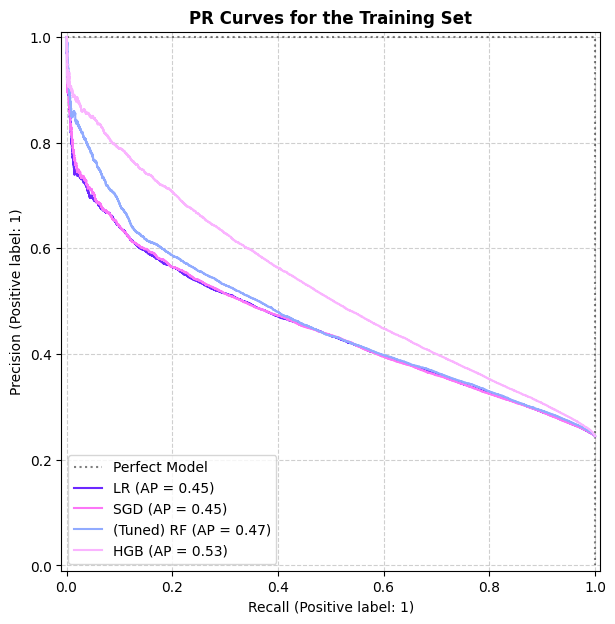

In [354]:
colours = {
    "LR": "#6c28ff",
    "SGD": "#fc76f7",
    "(Tuned) RF": "#91abff",
    "HGB": "#fab4ff"
}

plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.plot([0, 1, 1], [1, 1, 0], color='black', linestyle=':', label='Perfect Model', alpha=0.5)

for name, data in training_model_results.items():
    PrecisionRecallDisplay.from_predictions(
        train_labels, 
        data['probs'], 
        name=name, 
        ax=ax,
        color=colours.get(name, 'black')
    )

plt.title("PR Curves for the Training Set", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# We can see that HGB may indeed the most promising model to fine-tine, since it's the closest to the "perfect classifier"
# Which is shown by a dotted line
# Now we need to plot validation performance to check for overfitting to see if HGB is actually good or just memorising the training data

Look at how all models performed on the **validation data** side by side.

In [355]:
validation_model_results = {}

validation_model_results["LR"] = {
        'preds': lr_preds_val,
        'probs': lr_probs_val,
        'recall': recall_score(validation_labels, lr_preds_val),
        'f1': f1_score(validation_labels, lr_preds_val)
    }

validation_model_results["SGD"] = {
        'preds': sgd_preds_val,
        'probs': sgd_probs_val,
        'recall': recall_score(validation_labels, sgd_preds_val),
        'f1': f1_score(validation_labels, sgd_preds_val)
    }

validation_model_results["(Tuned) RF"] = {
        'preds': new_rf_preds_val,
        'probs': new_rf_probs_val,
        'recall': recall_score(validation_labels, new_rf_preds_val),
        'f1': f1_score(validation_labels, new_rf_preds_val)
    }

validation_model_results["HGB"] = {
        'preds': hgb_preds_val,
        'probs': hgb_probs_val,
        'recall': recall_score(validation_labels, hgb_preds_val),
        'f1': f1_score(validation_labels, hgb_preds_val)
    }

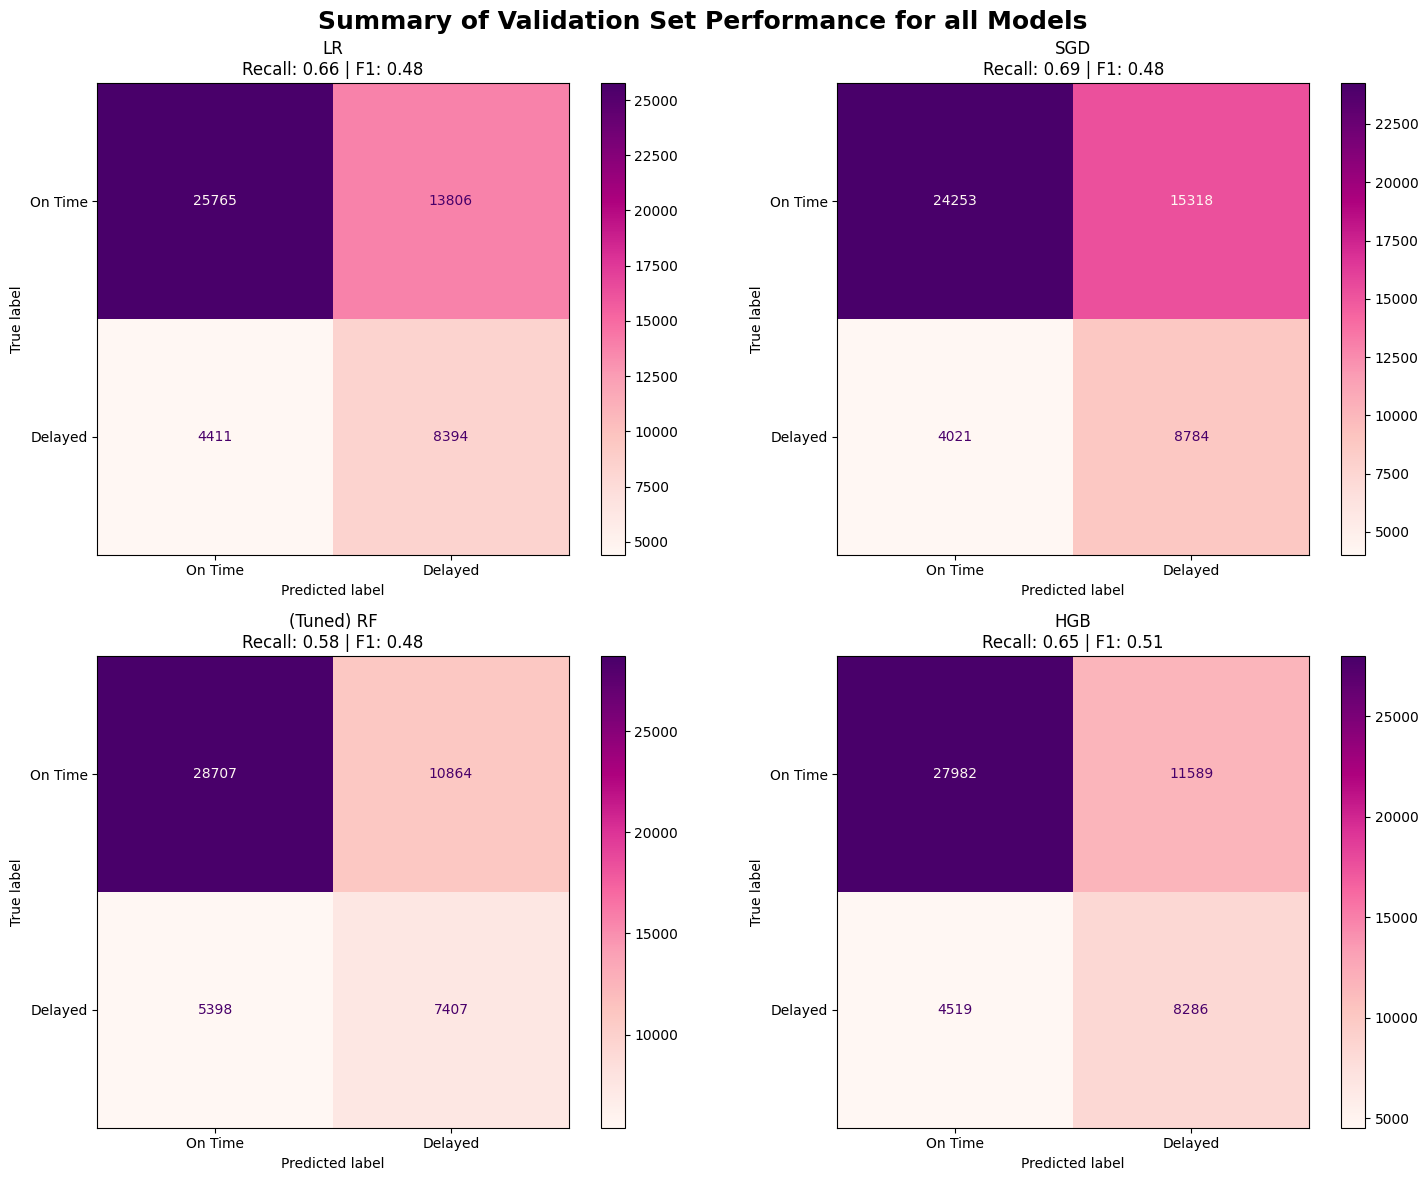

In [356]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(validation_model_results.items()):
    cm = confusion_matrix(validation_labels, data['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
    disp.plot(ax=axes[i], cmap='RdPu', colorbar=True)
    axes[i].set_title(f"{name}\nRecall: {data['recall']:.2f} | F1: {data['f1']:.2f}")

plt.suptitle("Summary of Validation Set Performance for all Models", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# HGB, like the other models, has a very similar recall and F1 score to the training data
# (apart from random forest which we had to fine to get an appropriate comparison)
# This means that it's unlikely to be overfitting or underfitting and is generalising well to new data

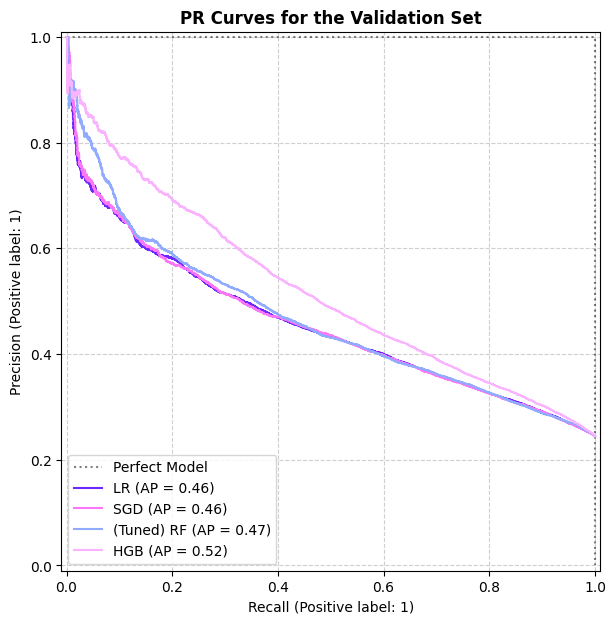

In [357]:
plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.plot([0, 1, 1], [1, 1, 0], color='black', linestyle=':', label='Perfect Model', alpha=0.5)

for name, data in validation_model_results.items():
    PrecisionRecallDisplay.from_predictions(
        validation_labels, 
        data['probs'], 
        name=name, 
        ax=ax,
        color=colours.get(name, 'black')
    )

plt.title("PR Curves for the Validation Set", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# This fortifies HGB as the top pick for fine tuning, since it has the largest AUC on the PR curve, so it balances precision/recall the best overall
# Remember the dataset is imbalanced (0.25 delayed vs 0.75 on time)
# This is probably why all PR curves are being dragged downwards into a convex shape rather than a concave one which would be more ideal
# This is because we have less delayed flights to train the data on
# https://sinyi-chou.github.io/classification-pr-curve/

## Fine Tune the Best Model

We will fine tune the histogram-based gradient boosting classifier which had recall of 0.65 and F1-score of 0.51.

In [ ]:
# Define the parameter grid
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],        # Smaller steps vs. aggressive learning
    'max_iter': [100, 300, 500, 1000],              # More boosting stages (use with early stopping)
    'max_leaf_nodes': [15, 31, 63, 127],            # Common powers of 2 minus 1
    'max_depth': [None, 5, 10, 15],                 # None allows growth until max_leaf_nodes
    'min_samples_leaf': [20, 50, 100, 200, 500],    # Higher values prevent overfitting on small flight patterns
    'l2_regularization': [0.0, 0.1, 1.0, 10.0],     # Added to penalise overly complex trees
    'max_bins': [128, 255]                          # Number of bins for the histogram
}

# Run the randomised search
random_search = RandomizedSearchCV(
    estimator=hist_gradient_boosting_model,
    param_distributions=param_dist,
    n_iter=50, # Number of random combinations to try (increased for better coverage)
    scoring='recall', # prioritising recall over precision
    cv=5, # k-fold cross-validation (I used 5 but this took 35m so wouldn't recommend rerunning!)
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available processors
)

# Retrain the best model on the full training set (including the validation set)
# Combine the prepared training and validation data
full_prepared_data = np.vstack([prepared_training_data, prepared_validation_data])
full_prepared_labels = np.concatenate([train_labels, validation_labels])

# Fit on the combined data
random_search.fit(full_prepared_data, full_prepared_labels)

# Extract the best model
final_hgb_model = random_search.best_estimator_
print(f"Best parameters: {random_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'min_samples_leaf': 500, 'max_leaf_nodes': 31, 'max_iter': 1000, 'max_depth': 10, 'max_bins': 255, 'learning_rate': 0.1, 'l2_regularization': 1.0}


In [404]:
# Trying again with some metrics that performed best at the "top" of their array, indicating the model wanted to learn more
# Re-define the parameter grid
param_dist = {
    'learning_rate': [0.075, 0.1, 0.125],
    'max_iter': [1000],
    'max_leaf_nodes': [31],
    'max_depth': [10],
    'min_samples_leaf': [400, 500, 600],
    'l2_regularization': [0.5, 1.0, 2.0],
    'max_bins': [128, 255]
}

# Run the randomised search
new_random_search = RandomizedSearchCV(
    estimator=hist_gradient_boosting_model,
    param_distributions=param_dist,
    n_iter=30, # Number of random combinations to try (increased for better coverage)
    scoring='recall', # prioritising recall over precision
    cv=3, # k-fold cross-validation (now using 3 to save computation expense)
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available processors
)

# Retrain the best model on the full training set (including the validation set)
# Combine the prepared training and validation data
full_prepared_data = pd.concat([prepared_training_data, prepared_validation_data], axis=0)
full_prepared_labels = pd.concat([train_labels, validation_labels], axis=0)

# Fit on the combined data
new_random_search.fit(full_prepared_data, full_prepared_labels)

# Update the best model
new_final_hgb_model = new_random_search.best_estimator_
print(f"Best parameters: {new_random_search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'min_samples_leaf': 600, 'max_leaf_nodes': 31, 'max_iter': 1000, 'max_depth': 10, 'max_bins': 128, 'learning_rate': 0.125, 'l2_regularization': 1.0}


Now we evaluate the tuned model on the **test set** to see how it generalises to new data.

In [405]:
# Evaluate the final model on the TEST SET
final_model_preds = new_final_hgb_model.predict(prepared_test_data)
final_model_probs = new_final_hgb_model.predict_proba(prepared_test_data)

# Check Recall and F1
tuned_recall = recall_score(test_labels, final_model_preds)
tuned_f1 = f1_score(test_labels, final_model_preds)

print(f"Final Model Recall: {tuned_recall:.4f}")
print(f"Final Model F1: {tuned_f1:.4f}")

# Full report to see the Precision-Recall trade-off
print(classification_report(test_labels, final_model_preds, target_names=['On Time', 'Delayed']))

Final Model Recall: 0.6582
Final Model F1: 0.5224
              precision    recall  f1-score   support

     On Time       0.87      0.72      0.79     49447
     Delayed       0.43      0.66      0.52     16023

    accuracy                           0.71     65470
   macro avg       0.65      0.69      0.65     65470
weighted avg       0.76      0.71      0.72     65470



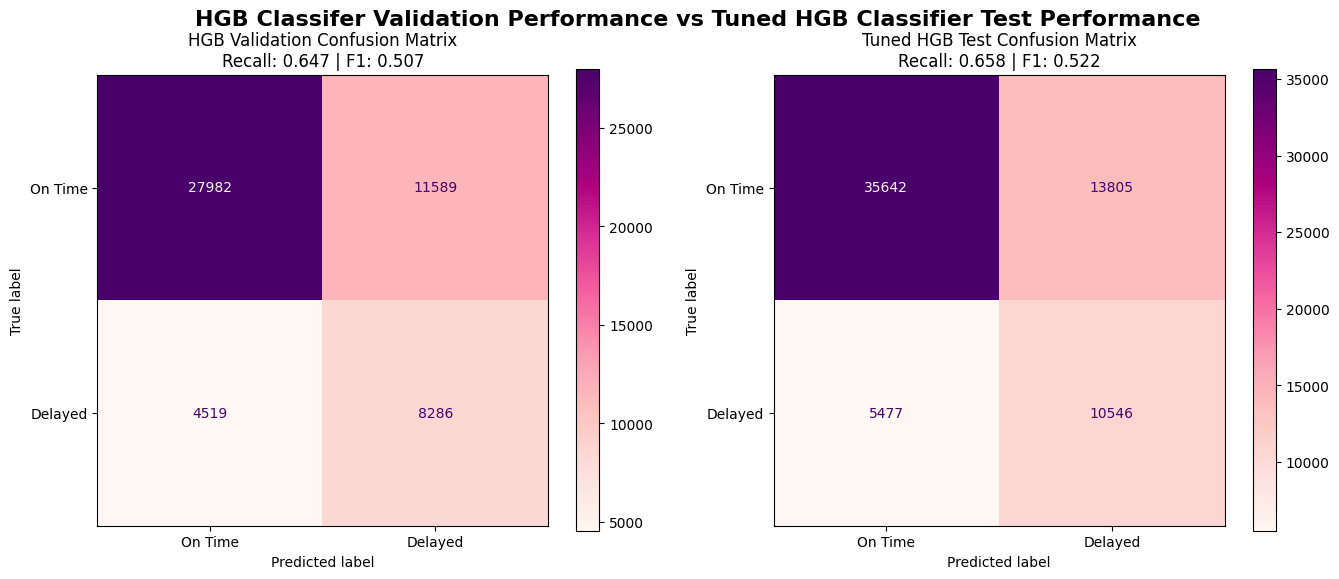

In [435]:
# Compare the fine tuned model with the old model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# HGB Validation Confusion Matrix (old)
hgb_cm_val = confusion_matrix(validation_labels, hgb_preds_val)
hgb_disp_val = ConfusionMatrixDisplay(confusion_matrix=hgb_cm_val, display_labels=['On Time', 'Delayed'])
hgb_disp_val.plot(ax=axes[0], cmap='RdPu', colorbar=True)
axes[0].set_title(f"HGB Validation Confusion Matrix\nRecall: {validation_model_results['HGB']['recall']:.3f} | F1: {validation_model_results['HGB']['f1']:.3f}", fontsize=12)

# Tuned HGB Test Confusion Matrix (new)
final_hbd_cm_test = confusion_matrix(test_labels, final_model_preds)
hgd_disp_test = ConfusionMatrixDisplay(confusion_matrix=final_hbd_cm_test, display_labels=['On Time', 'Delayed'])
hgd_disp_test.plot(ax=axes[1], cmap='RdPu', colorbar=True)
axes[1].set_title(f"Tuned HGB Test Confusion Matrix\nRecall: {tuned_recall:.3f} | F1: {tuned_f1:.3f}", fontsize=12)

plt.suptitle("HGB Classifer Validation Performance vs Tuned HGB Classifier Test Performance", fontsize=16, fontweight='bold')
plt.show()

### Aside: AUC-ROC Curve

This graph was plotted to see how 'good' the model is across a range of thresholds to give a more holistic view of the model's performance.

However, given that we know the dataset is imbalanced (~25% flights are delayed, ~75% are on time), the precision recall curve is more reliable than ROC curves.

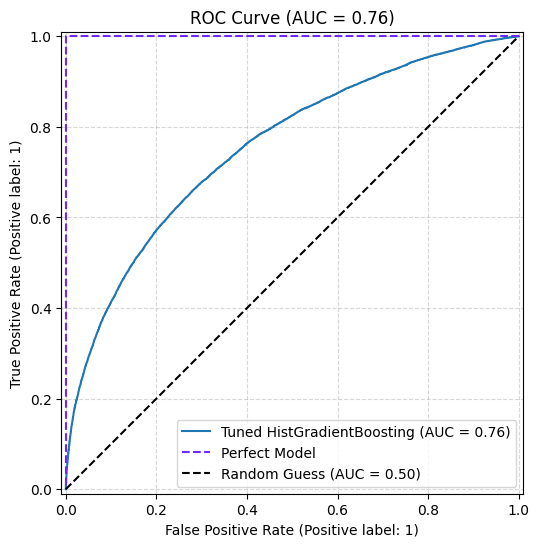

In [432]:
# Calculate the ROC-AUC score
pos_final_model_probs = final_model_probs[:, 1]
roc_auc = roc_auc_score(test_labels, pos_final_model_probs)

# Plot the ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
display = RocCurveDisplay.from_predictions(
    test_labels, 
    pos_final_model_probs, 
    name="Tuned HistGradientBoosting", 
    ax=ax
)

# Adding the random guess line and perfect classifier line for comparison
plt.plot([1, 0, 0], [1, 1, 0], "--", label="Perfect Model", color='#6c28ff')
plt.plot([0, 1], [0, 1], "--", label="Random Guess (AUC = 0.50)", color='black')

ax.set_title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# We can see the ROC-AUC score is 0.76, a better score than the PR curve
# This is to be expected as it is not as representative of the imbalanced dataset but is still somewhat useful

### Aside: Feature Importances

This was used during feature selection and fine tuning to ensure the model wasn't overfitting by inspecting to see if there was too heavy a dependence on a particular attribute.

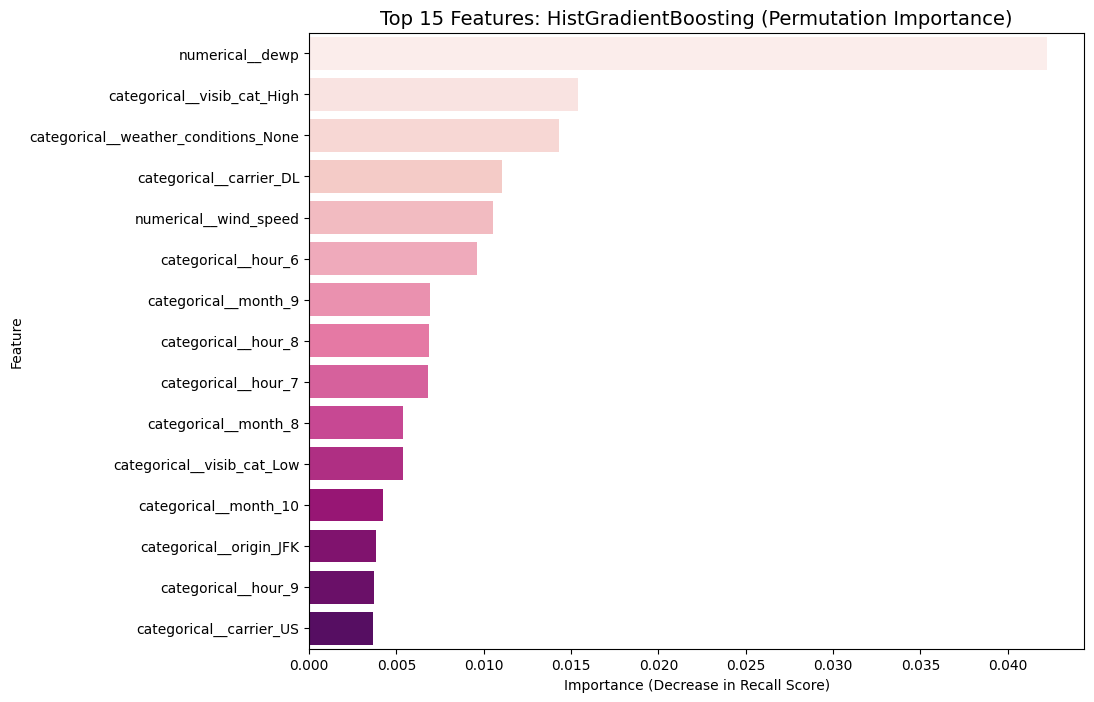

In [ ]:
from sklearn.inspection import permutation_importance
# https://sklearner.com/scikit-learn-permutation_importance/
# https://scikit-learn.ru/stable/modules/generated/sklearn.inspection.permutation_importance.html

# Calculate Permutation Importance
result = permutation_importance(
    final_hgb_model, 
    prepared_test_data, 
    test_labels, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

# Retrieve the feature names from the pipeline
feature_names = full_pipeline.get_feature_names_out()

# Create the DataFrame from the result so we can plot it
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='RdPu',
    legend=False
)
plt.title('Top 15 Features: HistGradientBoosting (Feature Importance)', fontsize=14)
plt.xlabel('Importance (Decrease in Recall Score)')
plt.ylabel('Feature')
plt.show()